# The Impact of Weight Quantization on Fake Image Detection

**Primary objective:** Measure how quantization level (fp4/fp8/fp16) affects the detectability of AI-generated images across three pretrained detectors.

| Cell | Purpose |
|------|----------|
| 1 | Clone detector library + install dependencies |
| 2 | Mount Google Drive |
| 3 | Copy pretrained weights |
| 4 | Patch detectors to support SD3.5, SDXL, FLUX.1 |
| 5 | Build unified dataset structure |
| 6 | Install open_clip, copy CLIP-D weights, run all detectors |
| 7 | Collect and download results CSV |
| 8 | Baseline analysis — quantization as primary axis |
| 9 | Score distribution plots |
| 10 | Threshold calibration |
| 11 | Threshold transfer across quantization levels |
| 12 | Extended quantization visualizations |

In [1]:
!git clone https://github.com/truebees-ai/Image-Deepfake-Detectors-Public-Library.git
%cd /content/Image-Deepfake-Detectors-Public-Library
!pip install -r requirements.txt -q

Cloning into 'Image-Deepfake-Detectors-Public-Library'...
remote: Enumerating objects: 324, done.
remote: Counting objects: 100% (103/103), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 324 (delta 51), reused 35 (delta 35), pack-reused 221 (from 1)
Receiving objects: 100% (324/324), 23.08 MiB | 14.63 MiB/s, done.
Resolving deltas: 100% (115/115), done.
Filtering content: 100% (4/4), 184.93 MiB | 21.40 MiB/s, done.
/content/Image-Deepfake-Detectors-Public-Library
ERROR: Could not find a version that satisfies the requirement torch==2.4.0 (from versions: 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0, 2.11.0, 2.12.0, 2.12.1, 2.13.0)
ERROR: No matching distribution found for torch==2.4.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE = '/content/drive/MyDrive'
print('Drive mounted')

Mounted at /content/drive
Drive mounted


In [3]:
import os, shutil

WEIGHTS_DIR = f'{DRIVE}/weights'
REPO_ROOT   = '/content/Image-Deepfake-Detectors-Public-Library'

for det in ['CLIP-D', 'NPR', 'R50_nodown']:
    src     = f'{WEIGHTS_DIR}/detectors/{det}/checkpoint/pretrained/weights/best.pt'
    dst_dir = f'{REPO_ROOT}/detectors/{det}/checkpoint/pretrained/weights'
    os.makedirs(dst_dir, exist_ok=True)
    if os.path.exists(src):
        shutil.copy2(src, f'{dst_dir}/best.pt')
        print(f'{det}: OK')
    else:
        print(f'{det}: NOT FOUND — check path')

CLIP-D: OK
NPR: OK
R50_nodown: OK


In [4]:
OLD = "'realFORLAB':['FORLAB']"
NEW = ("'realFORLAB':['FORLAB'],\n"
       "        'sd35':['StableDiffusion3.5'],\n"
       "        'sdxl':['StableDiffusionXL'],\n"
       "        'flux':['FLUX.1']")

files_to_patch = [
    'detectors/CLIP-D/utils/dataset.py',
    'detectors/R50_nodown/utils/dataset.py',
    'detectors/NPR/data/__init__.py',
]
for path in files_to_patch:
    with open(path) as f:
        content = f.read()
    if 'sd35' in content:
        print(f'Already patched: {path}')
        continue
    if OLD not in content:
        print(f'ERROR: pattern not found in {path}')
        continue
    with open(path, 'w') as f:
        f.write(content.replace(OLD, NEW))
    with open(path) as f:
        check = f.read()
    print(f'{"OK" if "sd35" in check else "FAILED"}: {path}')

OK: detectors/CLIP-D/utils/dataset.py
OK: detectors/R50_nodown/utils/dataset.py
OK: detectors/NPR/data/__init__.py


In [5]:
import os, shutil, glob

DRIVE     = '/content/drive/MyDrive'
REPO_ROOT = '/content/Image-Deepfake-Detectors-Public-Library'
DEMO      = os.path.join(REPO_ROOT, 'demo_images', 'PreSocial')

GEN_MAP = {
    'sd15':  'StableDiffusion1.5',
    'sd3':   'StableDiffusion3',
    'sd35':  'StableDiffusion3.5',
    'sdxl':  'StableDiffusionXL',
    'flux':  'FLUX.1',
}

# Clean existing
demo_root = os.path.join(REPO_ROOT, 'demo_images')
if os.path.exists(demo_root):
    shutil.rmtree(demo_root)

real_dst = os.path.join(DEMO, 'Real', 'FORLAB', 'images')
os.makedirs(real_dst, exist_ok=True)

forlab_files = (
    glob.glob(f'{DRIVE}/FORLAB/*.jpg') +
    glob.glob(f'{DRIVE}/FORLAB/*.png')
)
for src in sorted(forlab_files):
    shutil.copy2(src, os.path.join(real_dst, os.path.basename(src)))
print(f'Real images: {len(forlab_files)}')

img2img_folders = {
    'img2img_medieval':   f'{DRIVE}/img2img_images/img2img_medieval',
    'img2img_origami':    f'{DRIVE}/img2img_images/img2img_origami',
    'img2img_vangogh':    f'{DRIVE}/img2img_images/img2img_van gogh style',
    'img2img_pastel':     f'{DRIVE}/img2img_images/img_2img_pastel',
}

img2img_count = {}
for prompt_key, folder in img2img_folders.items():
    if not os.path.exists(folder):
        print(f'MISSING: {folder}')
        continue
    for fpath in sorted(glob.glob(f'{folder}/*.png') + glob.glob(f'{folder}/*.jpg')):
        fname = os.path.basename(fpath)
        parts = os.path.splitext(fname)[0].split('_')
        if len(parts) < 3: continue
        model_key = parts[1]
        quant     = parts[2]
        if model_key not in GEN_MAP: continue
        dst_dir = os.path.join(DEMO, 'Fake', GEN_MAP[model_key], 'images')
        os.makedirs(dst_dir, exist_ok=True)
        new_name = f'img2img_{prompt_key}_{fname}'
        shutil.copy2(fpath, os.path.join(dst_dir, new_name))
        key = f'{GEN_MAP[model_key]}/{quant}'
        img2img_count[key] = img2img_count.get(key, 0) + 1

print('\nImg2img:')
for k, v in sorted(img2img_count.items()): print(f'  {k}: {v}')

for txt2img_root in [
    f'{DRIVE}/txt2img_images/txt2img_images',
    f'{DRIVE}/txt2img_images'
]:
    if os.path.exists(txt2img_root): break

txt2img_count = {}
for folder in sorted(os.listdir(txt2img_root)):
    folder_path = os.path.join(txt2img_root, folder)
    if not os.path.isdir(folder_path): continue
    parts = folder.split('_', 1)
    if len(parts) < 2: continue
    model_key = parts[0]
    quant     = parts[1]
    if model_key not in GEN_MAP: continue
    dst_dir = os.path.join(DEMO, 'Fake', GEN_MAP[model_key], 'images')
    os.makedirs(dst_dir, exist_ok=True)
    files = sorted(glob.glob(f'{folder_path}/*.png') + glob.glob(f'{folder_path}/*.jpg'))
    for fpath in files:
        fname    = os.path.basename(fpath)
        new_name = f'txt2img_{fname}'
        shutil.copy2(fpath, os.path.join(dst_dir, new_name))
    key = f'{GEN_MAP[model_key]}/{quant}'
    txt2img_count[key] = txt2img_count.get(key, 0) + len(files)

print('\nTxt2img:')
for k, v in sorted(txt2img_count.items()): print(f'  {k}: {v}')

total_fake = sum(img2img_count.values()) + sum(txt2img_count.values())
print(f'\nTotal real: {len(forlab_files)}')
print(f'Total fake: {total_fake}')

all_fakes = glob.glob(f'{DEMO}/Fake/*/images/*')
print('\nFake images by quantization level (PRIMARY AXIS):')
for q in ['fp4', 'fp8', 'fp16']:
    n = len([f for f in all_fakes if f'_{q}_' in os.path.basename(f)
             or f'_{q}.' in os.path.basename(f)])
    print(f'  {q}: {n}')

Real images: 1702

Img2img:
  StableDiffusion1.5/fp16: 120
  StableDiffusion1.5/fp4: 120
  StableDiffusion1.5/fp8: 120
  StableDiffusion3.5/fp16: 120
  StableDiffusion3.5/fp4: 119
  StableDiffusion3.5/fp8: 120
  StableDiffusion3/fp16: 120
  StableDiffusion3/fp4: 120
  StableDiffusion3/fp8: 120

Txt2img:
  FLUX.1/fp16: 200
  FLUX.1/fp4: 150
  FLUX.1/fp8: 200
  StableDiffusion1.5/fp16: 200
  StableDiffusion1.5/fp4: 200
  StableDiffusion1.5/fp8: 200
  StableDiffusion3.5/fp16: 200
  StableDiffusion3.5/fp4: 200
  StableDiffusion3.5/fp8: 200
  StableDiffusion3/fp16: 200
  StableDiffusion3/fp4: 200
  StableDiffusion3/fp8: 200
  StableDiffusionXL/fp16: 200
  StableDiffusionXL/fp4: 200
  StableDiffusionXL/fp8: 200

Total real: 1702
Total fake: 4029

Fake images by quantization level (PRIMARY AXIS):
  fp4: 1309
  fp8: 1360
  fp16: 1360


In [6]:
import os, json, sys, argparse

REPO_ROOT = '/content/Image-Deepfake-Detectors-Public-Library'
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

# Clear cached imports so patched files are used
for key in list(sys.modules.keys()):
    if any(x in key for x in ['launcher','dataset','datasets','data']):
        del sys.modules[key]

import launcher

def build_demo_split_json(root_path, out_path):
    test_entries = []
    for mod in ['PreSocial', 'Facebook', 'Telegram', 'X']:
        mod_path = os.path.join(root_path, mod)
        if not os.path.isdir(mod_path): continue
        for dirpath, dirnames, filenames in os.walk(mod_path, followlinks=True):
            imgs = [f for f in filenames
                    if os.path.splitext(f)[1].lower() in ['.png','.jpg','.jpeg']]
            if not imgs: continue
            rel   = os.path.relpath(dirpath, mod_path)
            parts = rel.split(os.sep)
            if len(parts) < 3: continue
            gen = parts[1]
            sub = parts[2]
            for fname in sorted(imgs):
                stem = os.path.splitext(fname)[0]
                test_entries.append(os.path.join(gen, sub, stem))
    unique = sorted(set(test_entries))
    with open(out_path, 'w') as f:
        json.dump({'test': unique}, f, indent=2)
    print(f'Split file: {len(unique)} entries')

DATA_KEYS = 'realFORLAB:pre&sd15:pre&sd3:pre&sd35:pre&sdXL:pre&flux:pre'

orig_load_config = launcher.load_config
def patched_load_config(config_path):
    config = orig_load_config(config_path)
    config['testing'] = [DATA_KEYS]
    return config

launcher.run_demo.__globals__['build_demo_split_json'] = build_demo_split_json
launcher.run_demo.__globals__['load_config'] = patched_load_config

DEMO_ROOT  = os.path.join(REPO_ROOT, 'demo_images')
split_path = os.path.join(REPO_ROOT, 'split_demo.json')
build_demo_split_json(DEMO_ROOT, split_path)

with open(split_path) as f:
    data = json.load(f)
print(f'Total entries: {len(data["test"])}')
print('Sample:', data['test'][:3])

import torch
print(f'\nCUDA: {torch.cuda.is_available()}')

# CLIP-D requires open_clip and weights in the demo checkpoint folder
!pip install -q open_clip_torch

import shutil as _shutil
_clipd_src = f'{REPO_ROOT}/detectors/CLIP-D/checkpoint/pretrained/weights/best.pt'
_clipd_dst_dir = f'{REPO_ROOT}/detectors/CLIP-D/checkpoint/demo/weights'
os.makedirs(_clipd_dst_dir, exist_ok=True)
_shutil.copy2(_clipd_src, f'{_clipd_dst_dir}/best.pt')
print('CLIP-D demo weights ready')

for detector in ['CLIP-D', 'NPR', 'R50_nodown']:
    print(f'\n{"+"*55}')
    print(f'Running: {detector}')
    print(f'{"+"*55}')
    launcher.run_demo(argparse.Namespace(
        demo=True, demo_detector=detector, config_dir='configs',
        weights_name=None, detect=False, image=None,
        weights='pretrained', output=None, dry_run=False,
        detector=None, phases='both',
    ))
    print(f'{detector} done.')

Split file: 5731 entries
Total entries: 5731
Sample: ['FLUX.1/images/txt2img_flux_fp16_p0_seed123', 'FLUX.1/images/txt2img_flux_fp16_p0_seed124', 'FLUX.1/images/txt2img_flux_fp16_p0_seed125']

CUDA: True
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.0 MB/s eta 0:00:00
CLIP-D demo weights ready

+++++++++++++++++++++++++++++++++++++++++++++++++++++++
Running: CLIP-D
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
[demo] Running CLIP-D test with args: --name "demo" --task test --device cuda:0 --split_file /content/Image-Deepfake-Detectors-Public-Library/split_demo.json --data_root /content/Image-Deepfake-Detectors-Public-Library/demo_images --data_keys "realFORLAB:pre&sd15:pre&sd3:pre&sd35:pre&sdXL:pre&flux:pre" --num_threads 8 --arch opencliplinearnext_clipL14commonpool --norm_type clip --resize_size 200 --resize_ratio 1 --resize_prob 0.2 --cmp_qual 65,100 --cmp_prob 0.5 --resizeSize 224
[d

In [7]:
import glob, pandas as pd, os
from google.colab import files

REPO_ROOT = '/content/Image-Deepfake-Detectors-Public-Library'

dfs = []
for csv_path in glob.glob(f'{REPO_ROOT}/detectors/*/results/**/*.csv', recursive=True):
    det = csv_path.replace(REPO_ROOT+'/detectors/','').split('/')[0]
    df  = pd.read_csv(csv_path, header=0, names=['path','score','label'])
    df['path']     = df['path'].str.strip()
    df['detector'] = det
    dfs.append(df)
    print(f'{det}: {len(df)} rows')

if not dfs:
    print('No results found.')
else:
    combined = pd.concat(dfs, ignore_index=True).drop_duplicates(subset=['path','detector'])

    def extract_quant(p):
        for q in ['fp4','fp8','fp16']:
            if f'_{q}_' in p or f'_{q}.' in p: return q
        return 'real'

    def extract_mode(p):
        if 'txt2img' in p: return 'txt2img'
        if 'img2img' in p: return 'img2img'
        return 'real'

    def extract_generator(p):
        for g in ['StableDiffusion3.5','StableDiffusion3','StableDiffusion1.5',
                  'StableDiffusionXL','FLUX.1','FORLAB']:
            if g in p: return g
        return 'unknown'

    combined['quant']     = combined['path'].apply(extract_quant)
    combined['mode']      = combined['path'].apply(extract_mode)
    combined['generator'] = combined['path'].apply(extract_generator)

    print(f'\nTotal rows: {len(combined)}')
    print('\nRows per detector/label:')
    print(combined.groupby(['detector','label']).size().to_string())
    print('\nFake rows per quant:')
    print(combined[combined['label']==1].groupby('quant').size().to_string())

    out = '/content/all_results.csv'
    combined.to_csv(out, index=False)
    files.download(out)
    print(f'\nSaved: {out}')

R50_nodown: 5731 rows
NPR: 5731 rows
CLIP-D: 5731 rows

Total rows: 17193

Rows per detector/label:
detector    label
CLIP-D      0.0      1702
            1.0      4029
NPR         0.0      1702
            1.0      4029
R50_nodown  0.0      1702
            1.0      4029

Fake rows per quant:
quant
fp16    4080
fp4     3927
fp8     4080


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Saved: /content/all_results.csv


1. ACCURACY ON REAL IMAGES (TNR)
Each detector's ability to correctly classify real images.
  CLIP-D        TNR=0.995  (n=1702 real images)
  NPR           TNR=0.998  (n=1702 real images)
  R50_nodown    TNR=0.999  (n=1702 real images)

2. DETECTION RATE PER QUANTIZATION LEVEL — PRIMARY FINDING
Fake images only. Does quantization level affect detectability?

  CLIP-D:
    fp4: TPR=0.975  n=1309
    fp8: TPR=0.942  n=1360
    fp16: TPR=0.924  n=1360

  NPR:
    fp4: TPR=0.309  n=1309
    fp8: TPR=0.326  n=1360
    fp16: TPR=0.448  n=1360

  R50_nodown:
    fp4: TPR=0.642  n=1309
    fp8: TPR=0.502  n=1360
    fp16: TPR=0.784  n=1360


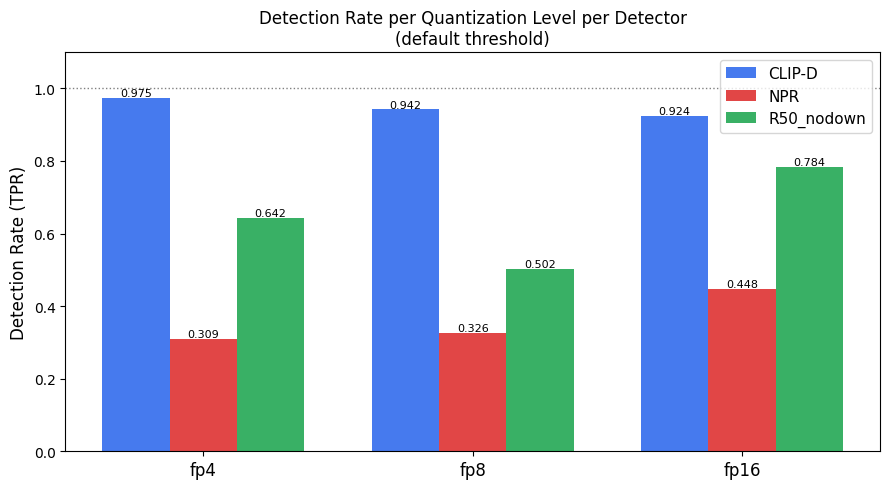

Saved: plot1_tpr_per_quant.png

3. DETECTION RATE PER QUANTIZATION PER GENERATOR
Does the quantization effect differ between generators?

  CLIP-D:
    FLUX.1                     fp4: 0.987(n=150)  fp8: 1.000(n=200)  fp16: 1.000(n=200)
    StableDiffusion1.5         fp4: 0.931(n=320)  fp8: 0.956(n=320)  fp16: 0.922(n=320)
    StableDiffusion3           fp4: 0.994(n=320)  fp8: 0.891(n=320)  fp16: 0.869(n=320)
    StableDiffusion3.5         fp4: 0.978(n=319)  fp8: 0.906(n=320)  fp16: 0.891(n=320)
    StableDiffusionXL          fp4: 1.000(n=200)  fp8: 1.000(n=200)  fp16: 0.995(n=200)

  NPR:
    FLUX.1                     fp4: 0.213(n=150)  fp8: 0.715(n=200)  fp16: 0.715(n=200)
    StableDiffusion1.5         fp4: 0.203(n=320)  fp8: 0.175(n=320)  fp16: 0.266(n=320)
    StableDiffusion3           fp4: 0.419(n=320)  fp8: 0.322(n=320)  fp16: 0.531(n=320)
    StableDiffusion3.5         fp4: 0.483(n=319)  fp8: 0.412(n=320)  fp16: 0.625(n=320)
    StableDiffusionXL          fp4: 0.095(n=200)  fp

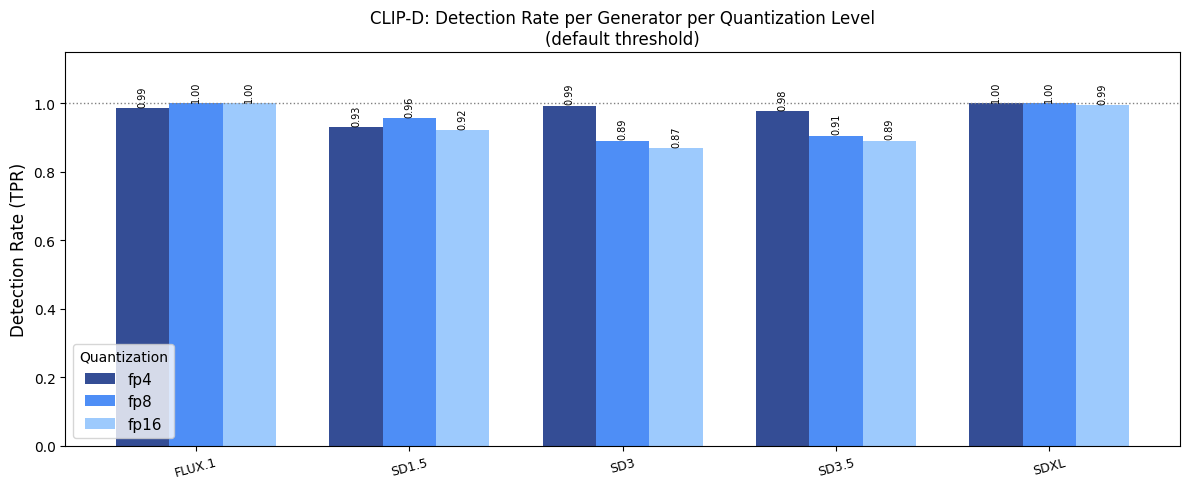

Saved: plot2_clipd_per_generator.png

4. AUC PER QUANTIZATION LEVEL (threshold-independent measure)
AUC measures ranking ability regardless of threshold.

  CLIP-D:
    fp4: AUC=0.999  n_fake=1309
    fp8: AUC=0.997  n_fake=1360
    fp16: AUC=0.997  n_fake=1360

  NPR:
    fp4: AUC=0.908  n_fake=1309
    fp8: AUC=0.908  n_fake=1360
    fp16: AUC=0.919  n_fake=1360

  R50_nodown:
    fp4: AUC=0.990  n_fake=1309
    fp8: AUC=0.991  n_fake=1360
    fp16: AUC=0.993  n_fake=1360


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score
from google.colab import files

df = pd.read_csv('/content/all_results.csv')
df.columns = df.columns.str.strip()
df['path'] = df['path'].str.strip()

def get_probs(s): return 1/(1+np.exp(-np.array(s, dtype=float)))
def get_preds(det, s):
    p = get_probs(s)
    return (p>0.5).astype(int) if det=='NPR' else (np.array(s)>0).astype(int)

QUANTS = ['fp4','fp8','fp16']
DETS   = ['CLIP-D','NPR','R50_nodown']
COLORS = {'CLIP-D':'#2563EB', 'NPR':'#DC2626', 'R50_nodown':'#16A34A'}

print('='*60)
print('1. ACCURACY ON REAL IMAGES (TNR)')
print('Each detector\'s ability to correctly classify real images.')
print('='*60)
real_df = df[df['label']==0.0]
for det, g in real_df.groupby('detector'):
    preds = get_preds(det, g['score'].values)
    # For real: correct = predicted 0 (real)
    tnr = (preds == 0).mean()
    print(f'  {det:12s}  TNR={tnr:.3f}  (n={len(g)} real images)')

print('\n' + '='*60)
print('2. DETECTION RATE PER QUANTIZATION LEVEL — PRIMARY FINDING')
print('Fake images only. Does quantization level affect detectability?')
print('='*60)
fake_df = df[df['label']==1.0]
tpr_by_quant = {}  # {det: {quant: tpr}}
for det, dg in fake_df.groupby('detector'):
    tpr_by_quant[det] = {}
    print(f'\n  {det}:')
    for q in QUANTS:
        qg = dg[dg['quant']==q]
        if not len(qg): continue
        preds = get_preds(det, qg['score'].values)
        tpr = preds.mean()
        tpr_by_quant[det][q] = tpr
        print(f'    {q}: TPR={tpr:.3f}  n={len(qg)}')

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(QUANTS))
width = 0.25
for i, det in enumerate(DETS):
    vals = [tpr_by_quant.get(det, {}).get(q, 0) for q in QUANTS]
    bars = ax.bar(x + i*width, vals, width, label=det, color=COLORS[det], alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.005, f'{h:.3f}',
                ha='center', fontsize=8)
ax.set_xticks(x + width); ax.set_xticklabels(QUANTS, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Detection Rate (TPR)', fontsize=12)
ax.set_title('Detection Rate per Quantization Level per Detector\n(default threshold)', fontsize=12)
ax.legend(fontsize=11)
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1)
plt.tight_layout()
plt.savefig('/content/plot1_tpr_per_quant.png', dpi=150)
plt.show()
print('Saved: plot1_tpr_per_quant.png')

print('\n' + '='*60)
print('3. DETECTION RATE PER QUANTIZATION PER GENERATOR')
print('Does the quantization effect differ between generators?')
print('='*60)
for det, dg in fake_df.groupby('detector'):
    print(f'\n  {det}:')
    for gen, gg in dg.groupby('generator'):
        row = f'    {gen:25s}'
        for q in QUANTS:
            qg = gg[gg['quant']==q]
            if not len(qg):
                row += f'  {q}:  N/A '
            else:
                preds = get_preds(det, qg['score'].values)
                row += f'  {q}: {preds.mean():.3f}(n={len(qg)})'
        print(row)

det = 'CLIP-D'
dg = fake_df[fake_df['detector']==det]
generators = sorted(dg['generator'].unique())

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(generators))
width = 0.25
q_colors = {'fp4':'#1e3a8a', 'fp8':'#3b82f6', 'fp16':'#93c5fd'}
for i, q in enumerate(QUANTS):
    vals = []
    for gen in generators:
        qg = dg[(dg['generator']==gen) & (dg['quant']==q)]
        vals.append(get_preds(det, qg['score'].values).mean() if len(qg) else 0)
    bars = ax.bar(x + i*width, vals, width, label=q, color=q_colors[q], alpha=0.9)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x()+bar.get_width()/2, h+0.01, f'{h:.2f}',
                    ha='center', fontsize=7, rotation=90)
ax.set_xticks(x + width)
ax.set_xticklabels([g.replace('StableDiffusion','SD') for g in generators],
                   fontsize=9, rotation=15)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Detection Rate (TPR)', fontsize=12)
ax.set_title('CLIP-D: Detection Rate per Generator per Quantization Level\n(default threshold)', fontsize=12)
ax.legend(title='Quantization', fontsize=11)
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1)
plt.tight_layout()
plt.savefig('/content/plot2_clipd_per_generator.png', dpi=150)
plt.show()
print('Saved: plot2_clipd_per_generator.png')

print('\n' + '='*60)
print('4. AUC PER QUANTIZATION LEVEL (threshold-independent measure)')
print('AUC measures ranking ability regardless of threshold.')
print('='*60)
real_scores = {}
real_labels = {}
for det, g in df[df['label']==0.0].groupby('detector'):
    real_scores[det] = g['score'].values
    real_labels[det] = g['label'].values

for det, dg in fake_df.groupby('detector'):
    print(f'\n  {det}:')
    for q in QUANTS:
        qg = dg[dg['quant']==q]
        if not len(qg): continue
        # Combine real + this quant's fakes
        all_scores = np.concatenate([real_scores[det], qg['score'].values])
        all_labels = np.concatenate([real_labels[det], qg['label'].values])
        probs = get_probs(all_scores)
        auc = roc_auc_score(all_labels, probs) if len(np.unique(all_labels))>1 else 0
        print(f'    {q}: AUC={auc:.3f}  n_fake={len(qg)}')

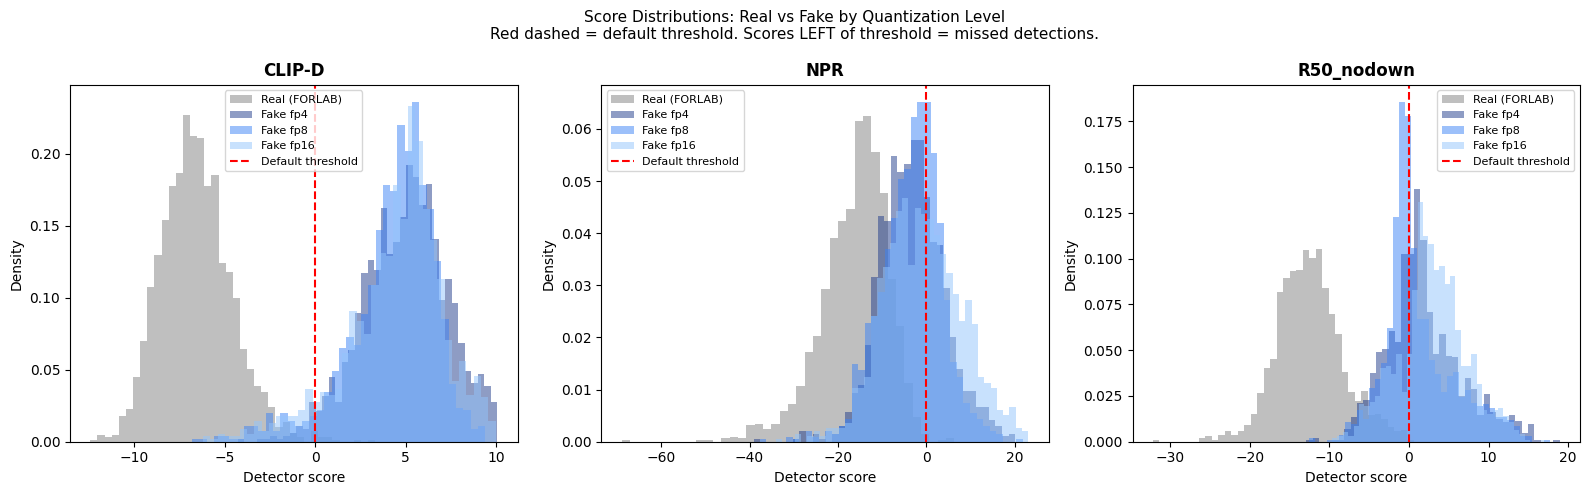

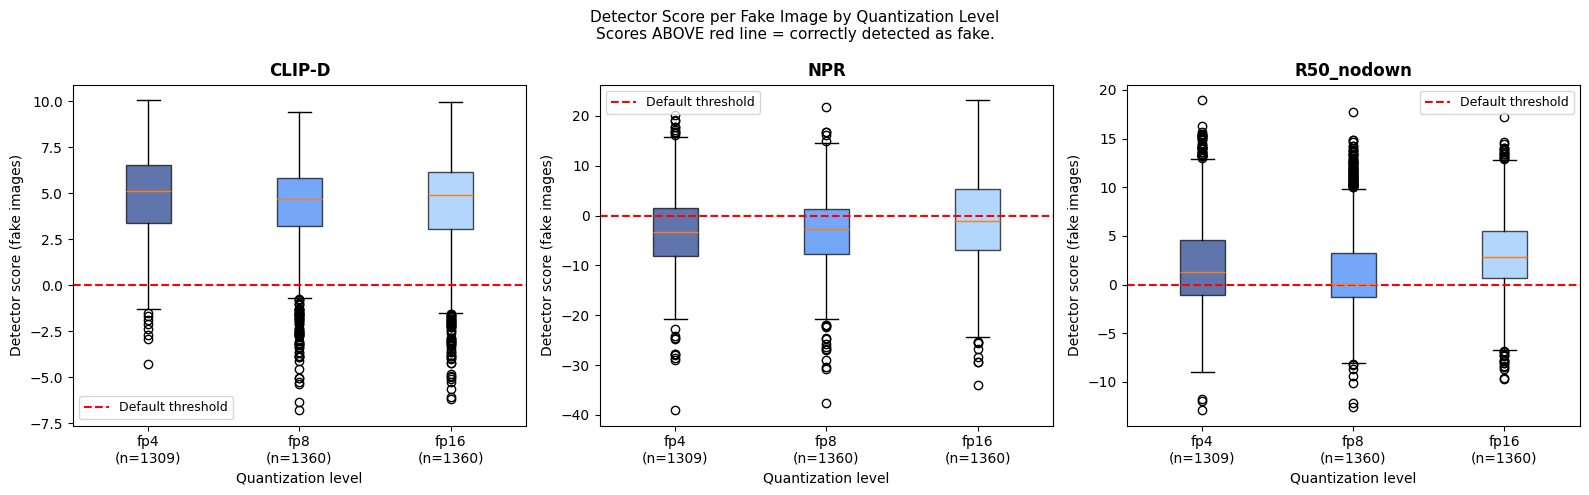

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Improvement B done.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import files

df = pd.read_csv('/content/all_results.csv')
df.columns = df.columns.str.strip()
df['path'] = df['path'].str.strip()

DETS     = ['CLIP-D','NPR','R50_nodown']
QUANTS   = ['fp4','fp8','fp16']
Q_COLORS = {'fp4':'#1e3a8a','fp8':'#3b82f6','fp16':'#93c5fd'}

# Plot Score distributions
fig, axes = plt.subplots(1,3, figsize=(16,5))
for ax, det in zip(axes, DETS):
    dg=df[df['detector']==det]
    real_s=dg[dg['label']==0]['score'].values
    if len(real_s):
        ax.hist(real_s, bins=40, alpha=0.5, color='gray',
                label='Real (FORLAB)', density=True)
    for q in QUANTS:
        fake_s=dg[(dg['label']==1)&(dg['quant']==q)]['score'].values
        if len(fake_s):
            ax.hist(fake_s, bins=40, alpha=0.5, color=Q_COLORS[q],
                    label=f'Fake {q}', density=True)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Default threshold')
    ax.set_title(f'{det}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Detector score', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=8)
plt.suptitle('Score Distributions: Real vs Fake by Quantization Level\n'
             'Red dashed = default threshold. Scores LEFT of threshold = missed detections.',
             fontsize=11)
plt.tight_layout()
plt.savefig('/content/plotB1_distributions.png', dpi=150); plt.show()

# Plot Boxplots
fig, axes = plt.subplots(1,3, figsize=(16,5))
for ax, det in zip(axes, DETS):
    dg=df[(df['detector']==det)&(df['label']==1)]
    data_to_plot=[]; tick_labels=[]; colors_used=[]
    for q in QUANTS:
        scores=dg[dg['quant']==q]['score'].values
        if len(scores):
            data_to_plot.append(scores)
            tick_labels.append(f'{q}\n(n={len(scores)})')
            colors_used.append(Q_COLORS[q])
    if not data_to_plot:
        ax.set_visible(False); continue
    bp=ax.boxplot(data_to_plot, tick_labels=tick_labels, patch_artist=True)
    for patch,color in zip(bp['boxes'], colors_used):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Default threshold')
    ax.set_title(f'{det}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Quantization level', fontsize=10)
    ax.set_ylabel('Detector score (fake images)', fontsize=10)
    ax.legend(fontsize=9)
plt.suptitle('Detector Score per Fake Image by Quantization Level\n'
             'Scores ABOVE red line = correctly detected as fake.',
             fontsize=11)
plt.tight_layout()
plt.savefig('/content/plotB2_boxplots.png', dpi=150); plt.show()

files.download('/content/plotB1_distributions.png')
files.download('/content/plotB2_boxplots.png')
print('Improvement B done.')

IMPROVEMENT A: THRESHOLD CALIBRATION
50/50 stratified split by label + quantization

  CLIP-D       threshold=0.1553 TPR=0.976 TNR=0.987 BalAcc=0.981 AUC=0.998
    fp4: TPR=0.998  n=655
    fp8: TPR=0.969  n=680
    fp16: TPR=0.960  n=680

  NPR          threshold=0.0003 TPR=0.782 TNR=0.881 BalAcc=0.832 AUC=0.913
    fp4: TPR=0.757  n=655
    fp8: TPR=0.771  n=680
    fp16: TPR=0.818  n=680

  R50_nodown   threshold=0.0075 TPR=0.954 TNR=0.952 BalAcc=0.953 AUC=0.991
    fp4: TPR=0.953  n=655
    fp8: TPR=0.951  n=680
    fp16: TPR=0.957  n=680


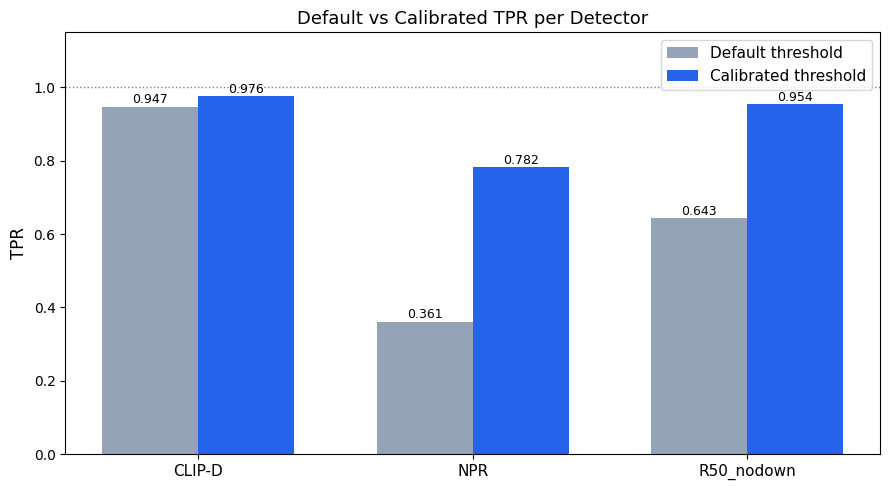

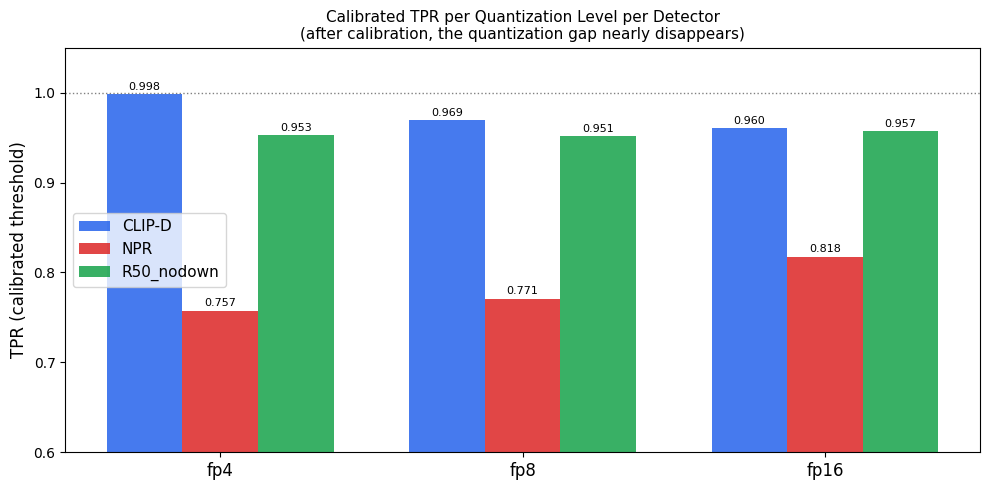

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Improvement A done.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score, balanced_accuracy_score
from sklearn.model_selection import train_test_split
from google.colab import files

df = pd.read_csv('/content/all_results.csv')
df.columns = df.columns.str.strip()
df['path'] = df['path'].str.strip()

def get_probs(s): return 1/(1+np.exp(-np.array(s, dtype=float)))
def get_preds(det, s):
    p = get_probs(s)
    return (p>0.5).astype(int) if det=='NPR' else (np.array(s)>0).astype(int)

DETS   = ['CLIP-D','NPR','R50_nodown']
QUANTS = ['fp4','fp8','fp16']
COLORS = {'CLIP-D':'#2563EB','NPR':'#DC2626','R50_nodown':'#16A34A'}
Q_COLORS = {'fp4':'#1e3a8a','fp8':'#3b82f6','fp16':'#93c5fd'}

print('='*60)
print('IMPROVEMENT A: THRESHOLD CALIBRATION')
print('50/50 stratified split by label + quantization')
print('='*60)

cal_thresholds={}; test_splits={}; cal_splits={}; tpr_default={}; tpr_cal={}

# Compute default TPR per quant first
fake_df = df[df['label']==1]
for det, dg in fake_df.groupby('detector'):
    tpr_default[det]={}
    for q in QUANTS:
        qg=dg[dg['quant']==q]
        if not len(qg): continue
        tpr_default[det][q]=get_preds(det,qg['score'].values).mean()

# Calibration
for det, g in df.groupby('detector'):
    if len(g['label'].unique())<2: continue
    g=g.copy()
    g['strat_key']=g['label'].astype(str)+'_'+g['quant'].fillna('real')
    min_count=g['strat_key'].value_counts().min()
    if min_count>=2:
        cal,test=train_test_split(g,test_size=0.5,stratify=g['strat_key'],random_state=42)
    else:
        cal,test=train_test_split(g,test_size=0.5,stratify=g['label'],random_state=42)
    cal_splits[det]=cal; test_splits[det]=test

    best_t,best_ba=0.5,0
    probs_cal=get_probs(cal['score'].values)
    for t in np.percentile(probs_cal,np.arange(1,100)):
        preds=(probs_cal>t).astype(int)
        ba=balanced_accuracy_score(cal['label'].values,preds)
        if ba>best_ba: best_ba,best_t=ba,t
    cal_thresholds[det]=best_t

    tp=get_probs(test['score'].values); l=test['label'].values
    preds=(tp>best_t).astype(int)
    f=l==1; r=l==0
    tpr=accuracy_score(l[f],preds[f]) if f.sum() else 0
    tnr=accuracy_score(l[r],preds[r]) if r.sum() else 0
    ba=balanced_accuracy_score(l,preds)
    auc=roc_auc_score(l,tp)
    print(f'\n  {det:12s} threshold={best_t:.4f} TPR={tpr:.3f} TNR={tnr:.3f} BalAcc={ba:.3f} AUC={auc:.3f}')

    tpr_cal[det]={}
    fake_test=test[test['label']==1]
    for q in QUANTS:
        qg=fake_test[fake_test['quant']==q]
        if not len(qg): continue
        qpreds=(get_probs(qg['score'].values)>best_t).astype(int)
        tpr_cal[det][q]=qpreds.mean()
        print(f'    {q}: TPR={qpreds.mean():.3f}  n={len(qg)}')

# Plot Default vs Calibrated TPR per detector
fig, ax = plt.subplots(figsize=(9,5))
x=np.arange(len(DETS)); width=0.35
default_vals=[get_preds(d, df[df['detector']==d]['score'].values)[df[df['detector']==d]['label'].values==1].mean() for d in DETS]
cal_vals=[]
for d in DETS:
    test=test_splits[d]; t=cal_thresholds[d]
    l=test['label'].values; f=l==1
    preds=(get_probs(test['score'].values)>t).astype(int)
    cal_vals.append(accuracy_score(l[f],preds[f]) if f.sum() else 0)

b1=ax.bar(x-width/2, default_vals, width, label='Default threshold', color='#94A3B8')
b2=ax.bar(x+width/2, cal_vals,     width, label='Calibrated threshold', color='#2563EB')
for bars in [b1,b2]:
    for bar in bars:
        h=bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.01, f'{h:.3f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(DETS, fontsize=11)
ax.set_ylim(0,1.15); ax.set_ylabel('TPR', fontsize=12)
ax.set_title('Default vs Calibrated TPR per Detector', fontsize=13)
ax.legend(fontsize=11); ax.axhline(1.0, color='gray', linestyle=':', linewidth=1)
plt.tight_layout()
plt.savefig('/content/plotA1_calibration.png', dpi=150); plt.show()

# Plot Calibrated TPR per quant per detector
fig, ax = plt.subplots(figsize=(10,5))
x=np.arange(len(QUANTS)); width=0.25
for i,det in enumerate(DETS):
    vals=[tpr_cal.get(det,{}).get(q,0) for q in QUANTS]
    bars=ax.bar(x+i*width, vals, width, label=det, color=COLORS[det], alpha=0.85)
    for bar in bars:
        h=bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.005, f'{h:.3f}', ha='center', fontsize=8)
ax.set_xticks(x+width); ax.set_xticklabels(QUANTS, fontsize=12)
ax.set_ylim(0.6,1.05); ax.set_ylabel('TPR (calibrated threshold)', fontsize=12)
ax.set_title('Calibrated TPR per Quantization Level per Detector\n(after calibration, the quantization gap nearly disappears)', fontsize=11)
ax.legend(fontsize=11); ax.axhline(1.0, color='gray', linestyle=':', linewidth=1)
plt.tight_layout()
plt.savefig('/content/plotA2_calibrated_per_quant.png', dpi=150); plt.show()

files.download('/content/plotA1_calibration.png')
files.download('/content/plotA2_calibrated_per_quant.png')
print('Improvement A done.')

IMPROVEMENT C: THRESHOLD TRANSFER ACROSS QUANTIZATION LEVELS
Calibrate on one quant level, evaluate on others.

  CLIP-D:
    Cal=fp4 → fp8: TPR=0.967(n=1360)  fp16: TPR=0.963(n=1360)  
    Cal=fp8 → fp4: TPR=0.995(n=1309)  fp16: TPR=0.966(n=1360)  
    Cal=fp16 → fp4: TPR=0.996(n=1309)  fp8: TPR=0.972(n=1360)  

  NPR:
    Cal=fp4 → fp8: TPR=0.783(n=1360)  fp16: TPR=0.801(n=1360)  
    Cal=fp8 → fp4: TPR=0.769(n=1309)  fp16: TPR=0.804(n=1360)  
    Cal=fp16 → fp4: TPR=0.756(n=1309)  fp8: TPR=0.779(n=1360)  

  R50_nodown:
    Cal=fp4 → fp8: TPR=0.961(n=1360)  fp16: TPR=0.965(n=1360)  
    Cal=fp8 → fp4: TPR=0.945(n=1309)  fp16: TPR=0.957(n=1360)  
    Cal=fp16 → fp4: TPR=0.943(n=1309)  fp8: TPR=0.954(n=1360)  


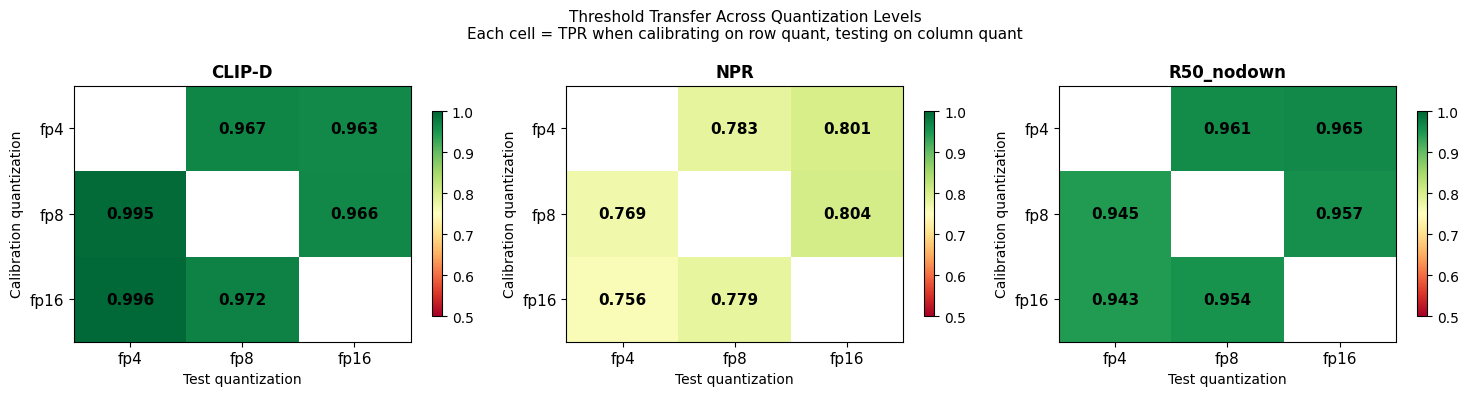

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Key finding: if transfer works well (all green), quantization levels
share the same artifact space and calibration generalizes across them.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import balanced_accuracy_score, accuracy_score
from google.colab import files

df = pd.read_csv('/content/all_results.csv')
df.columns = df.columns.str.strip()
df['path'] = df['path'].str.strip()

def get_probs(s): return 1/(1+np.exp(-np.array(s, dtype=float)))

DETS   = ['CLIP-D','NPR','R50_nodown']
QUANTS = ['fp4','fp8','fp16']

real_df = df[df['label']==0]
fake_df = df[df['label']==1]

print('='*60)
print('IMPROVEMENT C: THRESHOLD TRANSFER ACROSS QUANTIZATION LEVELS')
print('Calibrate on one quant level, evaluate on others.')
print('='*60)

transfer_results = {}  # {det: {cal_q: {test_q: tpr}}}

for det in DETS:
    print(f'\n  {det}:')
    transfer_results[det] = {}
    real_det = real_df[real_df['detector']==det]
    fake_det = fake_df[fake_df['detector']==det]

    for cal_q in QUANTS:
        cal_fake = fake_det[fake_det['quant']==cal_q]
        cal_set  = pd.concat([cal_fake, real_det])
        probs_cal = get_probs(cal_set['score'].values)
        labels_cal = cal_set['label'].values

        # Find best threshold on cal_q
        best_t, best_ba = 0.5, 0
        for t in np.percentile(probs_cal, np.arange(1,100)):
            preds=(probs_cal>t).astype(int)
            ba=balanced_accuracy_score(labels_cal,preds)
            if ba>best_ba: best_ba,best_t=ba,t

        transfer_results[det][cal_q] = {}
        row = f'    Cal={cal_q} → '
        for test_q in [q for q in QUANTS if q!=cal_q]:
            test_fake = fake_det[fake_det['quant']==test_q]
            if not len(test_fake): continue
            tp = get_probs(test_fake['score'].values)
            preds = (tp>best_t).astype(int)
            tpr = preds.mean()
            transfer_results[det][cal_q][test_q] = tpr
            row += f'{test_q}: TPR={tpr:.3f}(n={len(test_fake)})  '
        print(row)

fig, axes = plt.subplots(1,3, figsize=(15,4))
for ax, det in zip(axes, DETS):
    mat = np.full((3,3), np.nan)
    for i,cq in enumerate(QUANTS):
        for j,tq in enumerate(QUANTS):
            if cq!=tq and tq in transfer_results[det].get(cq,{}):
                mat[i,j] = transfer_results[det][cq][tq]
    im=ax.imshow(mat, cmap='RdYlGn', vmin=0.5, vmax=1.0, aspect='auto')
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(QUANTS, fontsize=11)
    ax.set_yticklabels(QUANTS, fontsize=11)
    ax.set_xlabel('Test quantization', fontsize=10)
    ax.set_ylabel('Calibration quantization', fontsize=10)
    ax.set_title(f'{det}', fontsize=12, fontweight='bold')
    for i in range(3):
        for j in range(3):
            if not np.isnan(mat[i,j]):
                ax.text(j,i,f'{mat[i,j]:.3f}', ha='center', va='center',
                        fontsize=11, fontweight='bold',
                        color='white' if mat[i,j]<0.65 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Threshold Transfer Across Quantization Levels\n'
             'Each cell = TPR when calibrating on row quant, testing on column quant',
             fontsize=11)
plt.tight_layout()
plt.savefig('/content/plotC_quant_transfer.png', dpi=150); plt.show()

files.download('/content/plotC_quant_transfer.png')
print('\nKey finding: if transfer works well (all green), quantization levels')
print('share the same artifact space and calibration generalizes across them.')

Calibrated thresholds: {'CLIP-D': np.float64(0.1553106103466794), 'NPR': np.float64(0.0002974937147381565), 'R50_nodown': np.float64(0.007540428473127475)}


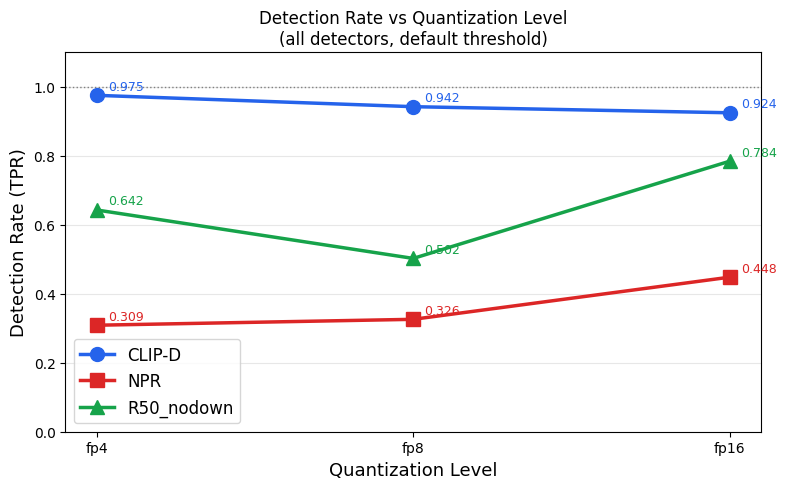

Plot 1 saved.


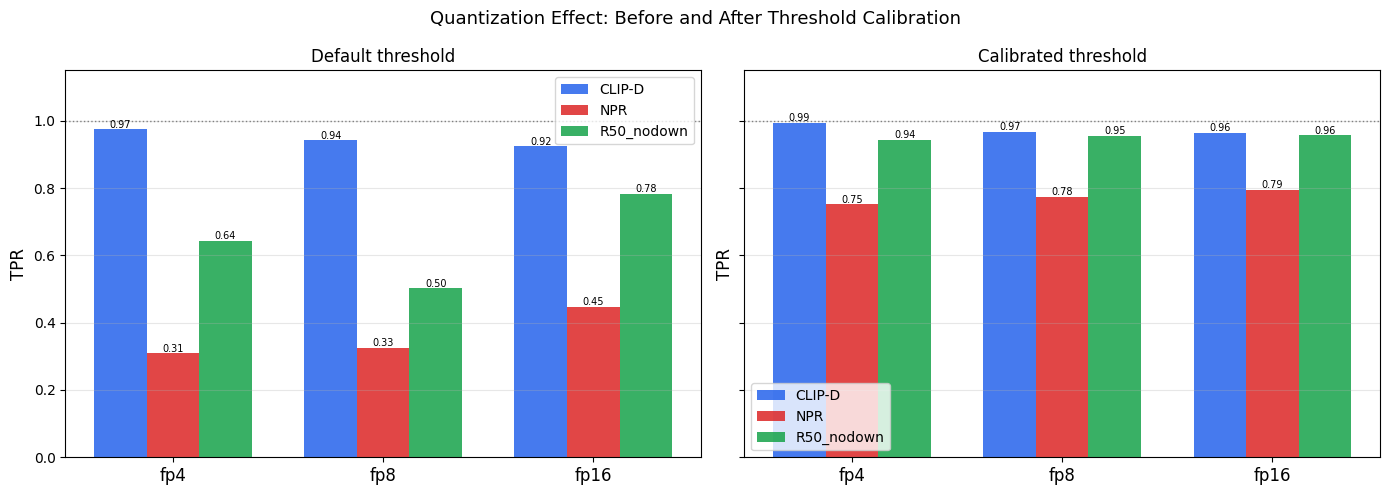

Plot 2 saved.


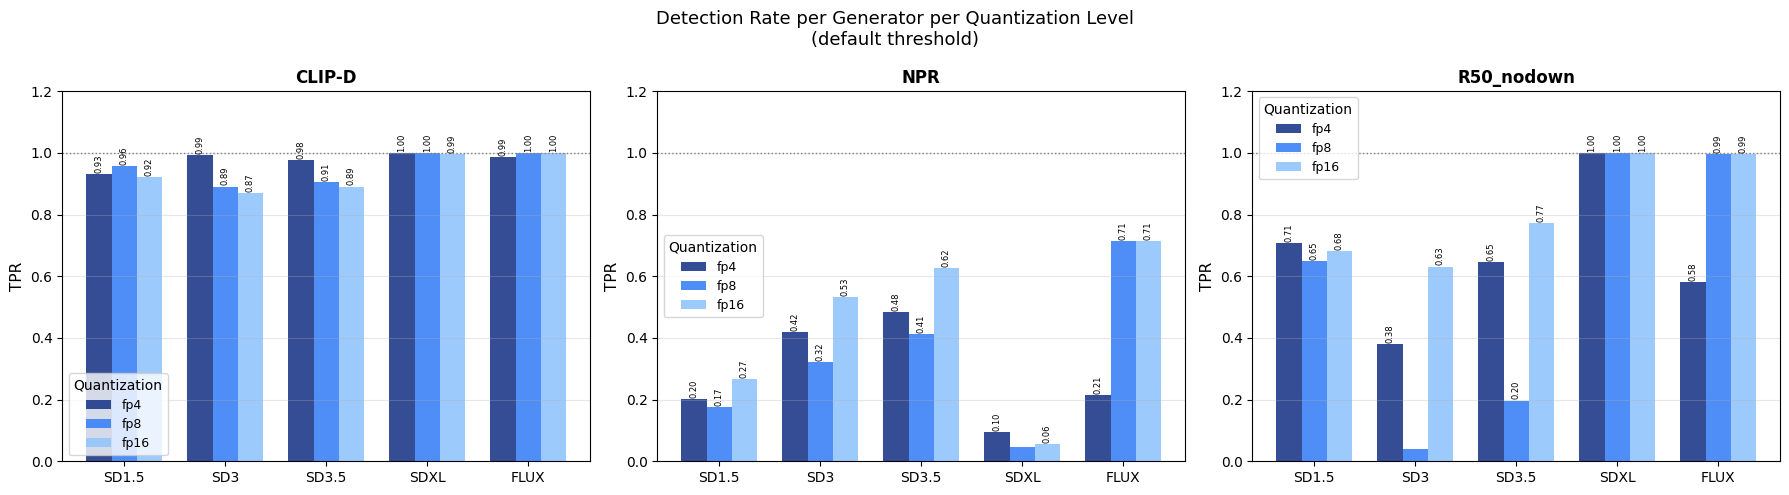

Plot 3 saved.


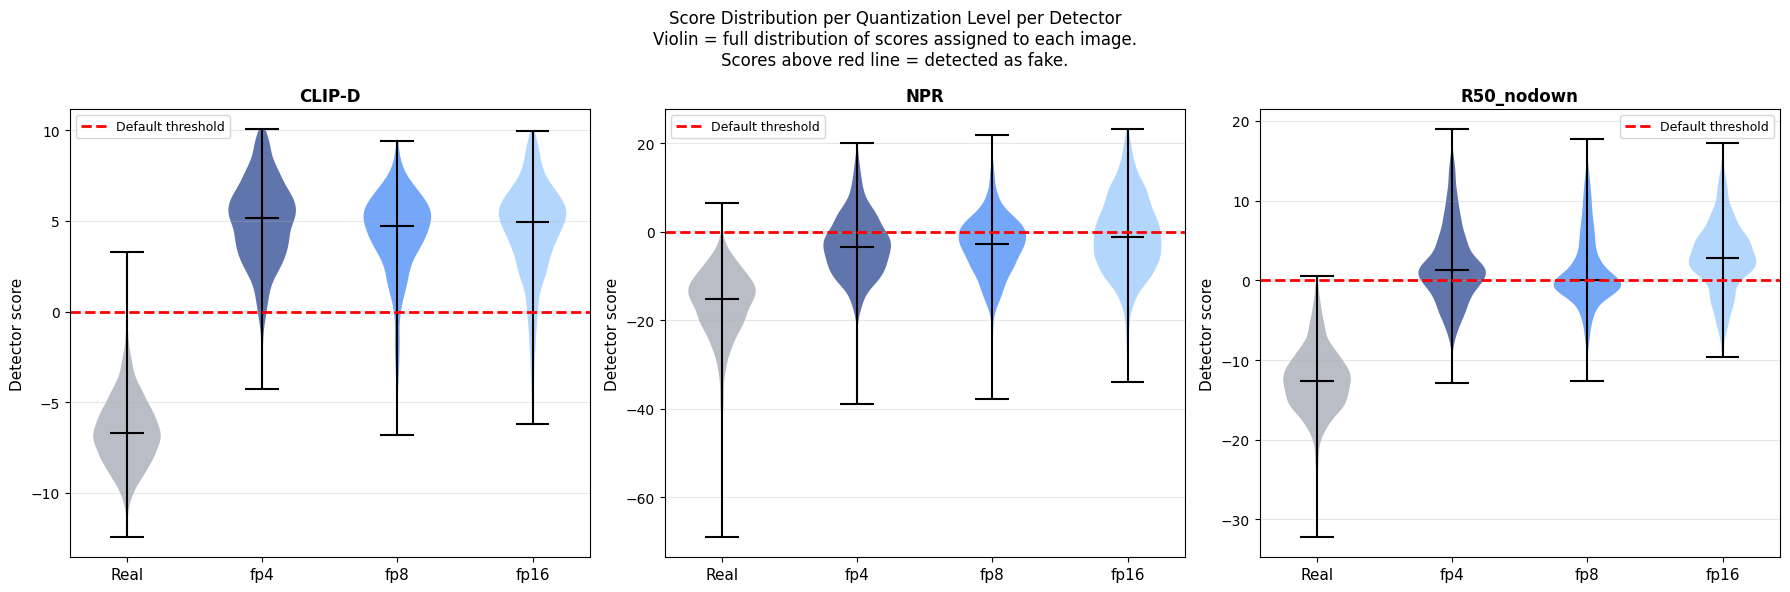

Plot 4 saved.


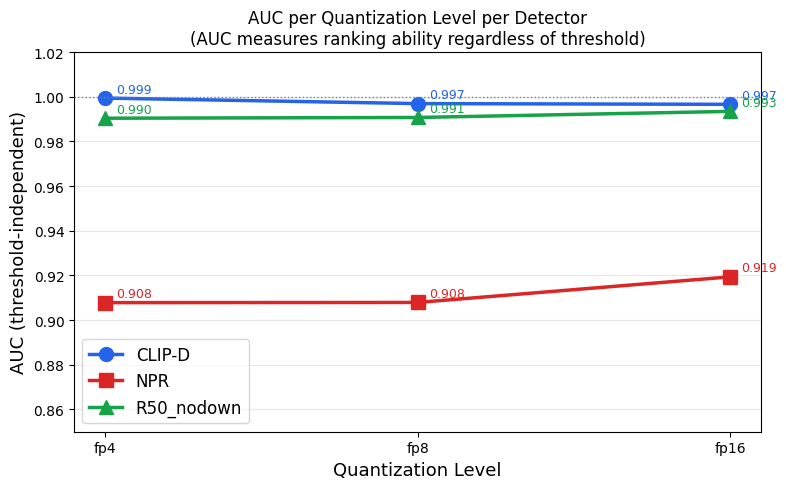

Plot 5 saved.


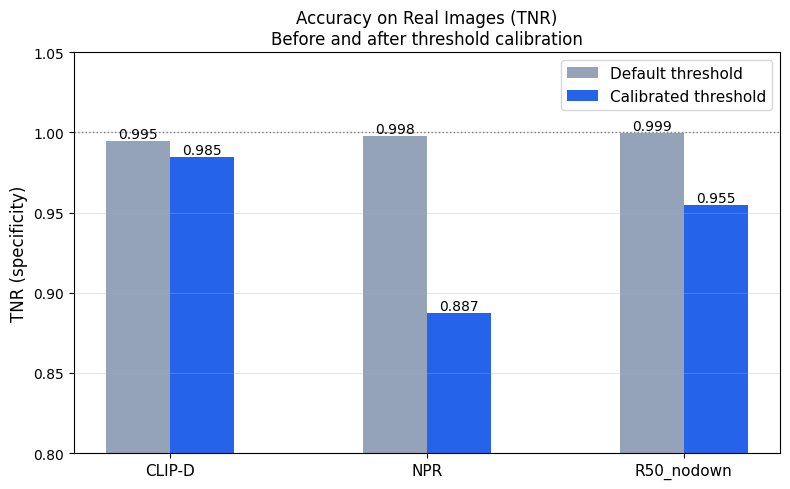

Plot 6 saved.


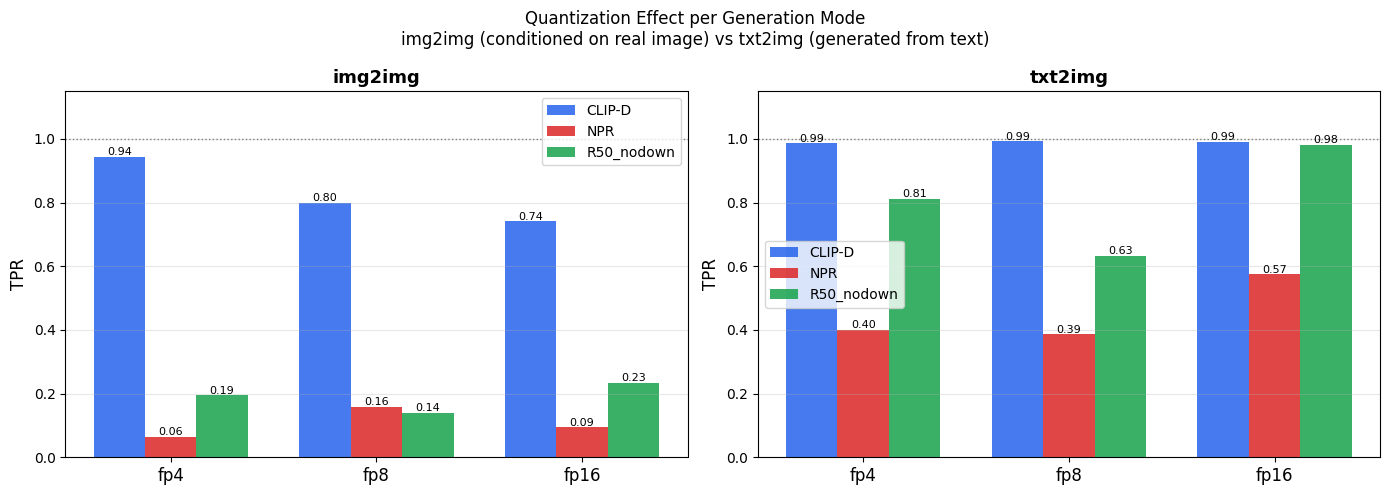

Plot 7 saved.


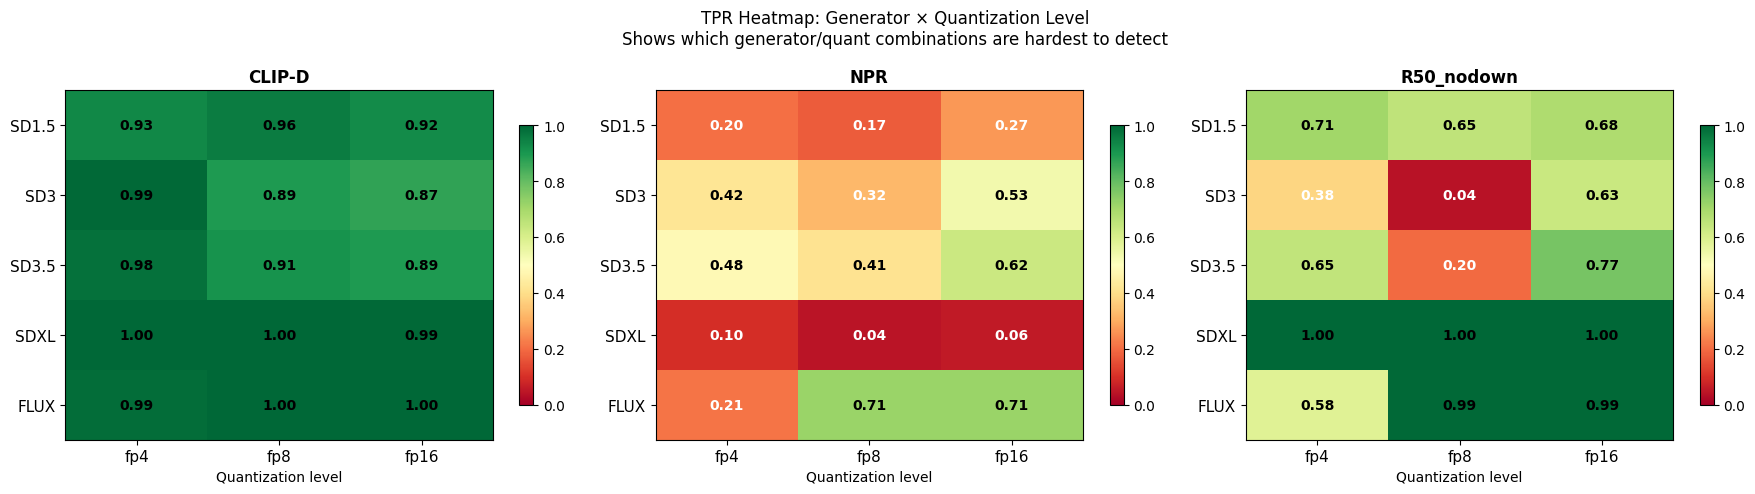

Plot 8 saved.


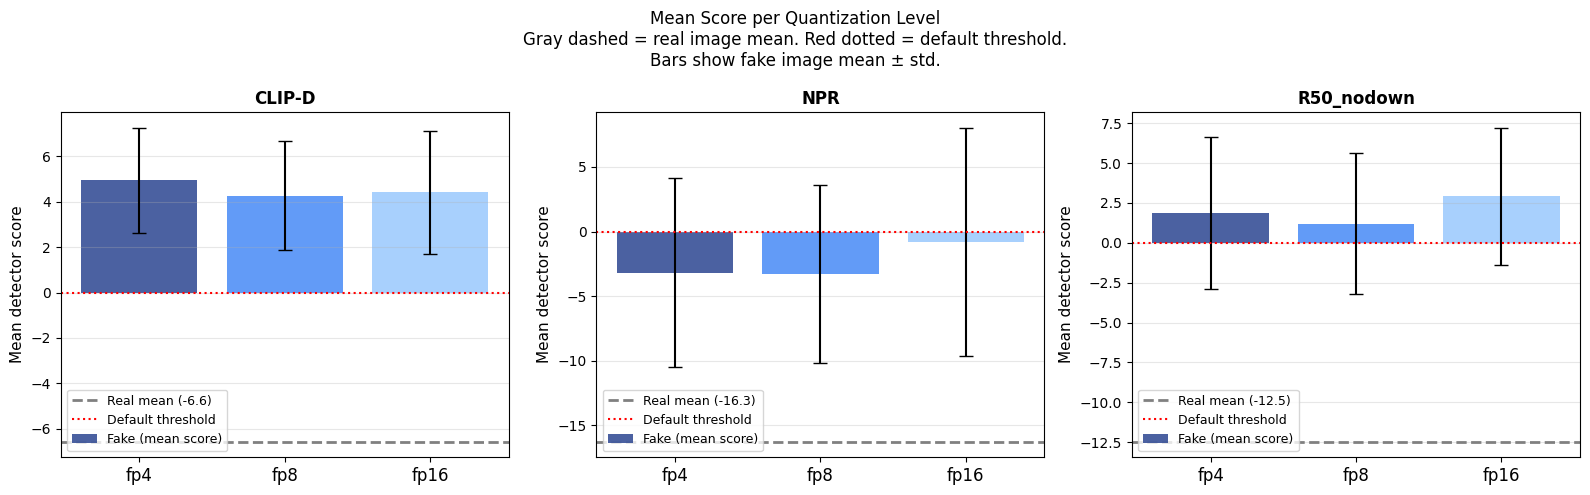

Plot 9 saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All plots downloaded.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score, balanced_accuracy_score
from sklearn.model_selection import train_test_split
from google.colab import files
import os

df = pd.read_csv('/content/all_results.csv')
df.columns = df.columns.str.strip()
df['path'] = df['path'].str.strip()

def get_probs(s): return 1/(1+np.exp(-np.array(s, dtype=float)))
def get_preds(det, s):
    p = get_probs(s)
    return (p>0.5).astype(int) if det=='NPR' else (np.array(s)>0).astype(int)

DETS     = ['CLIP-D', 'NPR', 'R50_nodown']
QUANTS   = ['fp4', 'fp8', 'fp16']
GENS     = ['StableDiffusion1.5','StableDiffusion3','StableDiffusion3.5',
            'StableDiffusionXL','FLUX.1']
COLORS   = {'CLIP-D':'#2563EB', 'NPR':'#DC2626', 'R50_nodown':'#16A34A'}
Q_COLORS = {'fp4':'#1e3a8a', 'fp8':'#3b82f6', 'fp16':'#93c5fd'}
DET_MARKERS = {'CLIP-D':'o', 'NPR':'s', 'R50_nodown':'^'}
fake_df  = df[df['label']==1]
real_df  = df[df['label']==0]

cal_thresholds = {}
for det, g in df.groupby('detector'):
    if len(g['label'].unique())<2: continue
    g = g.copy()
    g['strat_key'] = g['label'].astype(str)+'_'+g['quant'].fillna('real')
    min_count = g['strat_key'].value_counts().min()
    if min_count>=2:
        cal,_ = train_test_split(g,test_size=0.5,stratify=g['strat_key'],random_state=42)
    else:
        cal,_ = train_test_split(g,test_size=0.5,stratify=g['label'],random_state=42)
    best_t,best_ba=0.5,0
    probs_cal=get_probs(cal['score'].values)
    for t in np.percentile(probs_cal,np.arange(1,100)):
        preds=(probs_cal>t).astype(int)
        ba=balanced_accuracy_score(cal['label'].values,preds)
        if ba>best_ba: best_ba,best_t=ba,t
    cal_thresholds[det]=best_t

print('Calibrated thresholds:', cal_thresholds)

fig, ax = plt.subplots(figsize=(8,5))
for det in DETS:
    dg = fake_df[fake_df['detector']==det]
    tprs = []
    for q in QUANTS:
        qg = dg[dg['quant']==q]
        tprs.append(get_preds(det, qg['score'].values).mean() if len(qg) else 0)
    ax.plot(QUANTS, tprs, marker=DET_MARKERS[det], color=COLORS[det],
            linewidth=2.5, markersize=10, label=det)
    for i,(q,v) in enumerate(zip(QUANTS,tprs)):
        ax.annotate(f'{v:.3f}', (q,v), textcoords='offset points',
                    xytext=(8,4), fontsize=9, color=COLORS[det])

ax.set_ylim(0, 1.1)
ax.set_ylabel('Detection Rate (TPR)', fontsize=13)
ax.set_xlabel('Quantization Level', fontsize=13)
ax.set_title('Detection Rate vs Quantization Level\n(all detectors, default threshold)', fontsize=12)
ax.legend(fontsize=12); ax.grid(axis='y', alpha=0.3)
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1)
plt.tight_layout()
plt.savefig('/content/plot1_tpr_vs_quant_lines.png', dpi=150); plt.show()
print('Plot 1 saved.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, use_cal, title in [
    (axes[0], False, 'Default threshold'),
    (axes[1], True,  'Calibrated threshold'),
]:
    x = np.arange(len(QUANTS)); width = 0.25
    for i, det in enumerate(DETS):
        dg = fake_df[fake_df['detector']==det]
        vals = []
        for q in QUANTS:
            qg = dg[dg['quant']==q]
            if not len(qg): vals.append(0); continue
            if use_cal:
                preds = (get_probs(qg['score'].values) > cal_thresholds[det]).astype(int)
            else:
                preds = get_preds(det, qg['score'].values)
            vals.append(preds.mean())
        bars = ax.bar(x+i*width, vals, width, label=det, color=COLORS[det], alpha=0.85)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x()+bar.get_width()/2, h+0.005,
                    f'{h:.2f}', ha='center', fontsize=7)
    ax.set_xticks(x+width); ax.set_xticklabels(QUANTS, fontsize=12)
    ax.set_ylim(0, 1.15); ax.set_ylabel('TPR', fontsize=12)
    ax.set_title(title, fontsize=12); ax.legend(fontsize=10)
    ax.axhline(1.0, color='gray', linestyle=':', linewidth=1)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Quantization Effect: Before and After Threshold Calibration', fontsize=13)
plt.tight_layout()
plt.savefig('/content/plot2_default_vs_calibrated.png', dpi=150); plt.show()
print('Plot 2 saved.')

gen_short = {
    'StableDiffusion1.5': 'SD1.5',
    'StableDiffusion3':   'SD3',
    'StableDiffusion3.5': 'SD3.5',
    'StableDiffusionXL':  'SDXL',
    'FLUX.1':             'FLUX',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, det in zip(axes, DETS):
    dg = fake_df[fake_df['detector']==det]
    x = np.arange(len(GENS)); width = 0.25
    for i, q in enumerate(QUANTS):
        vals = []
        for gen in GENS:
            gg = dg[(dg['generator']==gen)&(dg['quant']==q)]
            vals.append(get_preds(det, gg['score'].values).mean() if len(gg) else 0)
        bars = ax.bar(x+i*width, vals, width, label=q,
                      color=Q_COLORS[q], alpha=0.9)
        for bar in bars:
            h = bar.get_height()
            if h > 0.05:
                ax.text(bar.get_x()+bar.get_width()/2, h+0.01,
                        f'{h:.2f}', ha='center', fontsize=6, rotation=90)
    ax.set_xticks(x+width)
    ax.set_xticklabels([gen_short[g] for g in GENS], fontsize=10)
    ax.set_ylim(0, 1.2); ax.set_ylabel('TPR', fontsize=11)
    ax.set_title(f'{det}', fontsize=12, fontweight='bold')
    ax.legend(title='Quantization', fontsize=9)
    ax.axhline(1.0, color='gray', linestyle=':', linewidth=1)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Detection Rate per Generator per Quantization Level\n'
             '(default threshold)', fontsize=13)
plt.tight_layout()
plt.savefig('/content/plot3_per_generator_per_quant.png', dpi=150); plt.show()
print('Plot 3 saved.')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, det in zip(axes, DETS):
    dg = fake_df[fake_df['detector']==det]
    real_d = real_df[real_df['detector']==det]['score'].values

    # Real + 3 quant levels
    all_data   = [real_d] + [dg[dg['quant']==q]['score'].values for q in QUANTS]
    all_labels = ['Real'] + QUANTS
    all_colors = ['#9CA3AF'] + [Q_COLORS[q] for q in QUANTS]

    parts = ax.violinplot(all_data, positions=range(len(all_data)),
                          showmedians=True, showextrema=True)
    for i,(pc,color) in enumerate(zip(parts['bodies'], all_colors)):
        pc.set_facecolor(color); pc.set_alpha(0.7)
    parts['cmedians'].set_color('black')
    parts['cmins'].set_color('black')
    parts['cmaxes'].set_color('black')
    parts['cbars'].set_color('black')

    # Default threshold line
    ax.axhline(0, color='red', linestyle='--', linewidth=2, label='Default threshold')
    ax.set_xticks(range(len(all_labels)))
    ax.set_xticklabels(all_labels, fontsize=11)
    ax.set_title(f'{det}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Detector score', fontsize=11)
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Score Distribution per Quantization Level per Detector\n'
             'Violin = full distribution of scores assigned to each image.\n'
             'Scores above red line = detected as fake.',
             fontsize=12)
plt.tight_layout()
plt.savefig('/content/plot4_violin_scores.png', dpi=150); plt.show()
print('Plot 4 saved.')

fig, ax = plt.subplots(figsize=(8,5))
for det in DETS:
    dg = fake_df[fake_df['detector']==det]
    real_s = real_df[real_df['detector']==det]['score'].values
    real_l = real_df[real_df['detector']==det]['label'].values
    aucs = []
    for q in QUANTS:
        qg = dg[dg['quant']==q]
        if not len(qg): aucs.append(0); continue
        all_s = np.concatenate([real_s, qg['score'].values])
        all_l = np.concatenate([real_l, qg['label'].values])
        aucs.append(roc_auc_score(all_l, get_probs(all_s)))
    ax.plot(QUANTS, aucs, marker=DET_MARKERS[det], color=COLORS[det],
            linewidth=2.5, markersize=10, label=det)
    for q,v in zip(QUANTS,aucs):
        ax.annotate(f'{v:.3f}', (q,v), textcoords='offset points',
                    xytext=(8,4), fontsize=9, color=COLORS[det])

ax.set_ylim(0.85, 1.02)
ax.set_ylabel('AUC (threshold-independent)', fontsize=13)
ax.set_xlabel('Quantization Level', fontsize=13)
ax.set_title('AUC per Quantization Level per Detector\n'
             '(AUC measures ranking ability regardless of threshold)', fontsize=12)
ax.legend(fontsize=12); ax.grid(axis='y', alpha=0.3)
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1)
plt.tight_layout()
plt.savefig('/content/plot5_auc_per_quant.png', dpi=150); plt.show()
print('Plot 5 saved.')

fig, ax = plt.subplots(figsize=(8,5))
x = np.arange(len(DETS)); width = 0.25

tnr_default = []
tnr_cal     = []
for det in DETS:
    real_d = real_df[real_df['detector']==det]
    preds_def = get_preds(det, real_d['score'].values)
    tnr_default.append((preds_def==0).mean())
    preds_cal = (get_probs(real_d['score'].values) > cal_thresholds[det]).astype(int)
    tnr_cal.append((preds_cal==0).mean())

b1 = ax.bar(x-width/2, tnr_default, width, label='Default threshold', color='#94A3B8')
b2 = ax.bar(x+width/2, tnr_cal,     width, label='Calibrated threshold', color='#2563EB')
for bars in [b1,b2]:
    for bar in bars:
        h=bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.002,
                f'{h:.3f}', ha='center', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(DETS, fontsize=11)
ax.set_ylim(0.8, 1.05); ax.set_ylabel('TNR (specificity)', fontsize=12)
ax.set_title('Accuracy on Real Images (TNR)\nBefore and after threshold calibration', fontsize=12)
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1)
plt.tight_layout()
plt.savefig('/content/plot6_tnr_real_images.png', dpi=150); plt.show()
print('Plot 6 saved.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mode in zip(axes, ['img2img','txt2img']):
    mode_df = fake_df[fake_df['mode']==mode]
    x = np.arange(len(QUANTS)); width = 0.25
    for i, det in enumerate(DETS):
        dg = mode_df[mode_df['detector']==det]
        vals = []
        for q in QUANTS:
            qg = dg[dg['quant']==q]
            vals.append(get_preds(det, qg['score'].values).mean() if len(qg) else 0)
        bars = ax.bar(x+i*width, vals, width, label=det, color=COLORS[det], alpha=0.85)
        for bar in bars:
            h=bar.get_height()
            ax.text(bar.get_x()+bar.get_width()/2, h+0.005,
                    f'{h:.2f}', ha='center', fontsize=8)
    ax.set_xticks(x+width); ax.set_xticklabels(QUANTS, fontsize=12)
    ax.set_ylim(0, 1.15); ax.set_ylabel('TPR', fontsize=12)
    ax.set_title(f'{mode}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
    ax.axhline(1.0, color='gray', linestyle=':', linewidth=1)

plt.suptitle('Quantization Effect per Generation Mode\n'
             'img2img (conditioned on real image) vs txt2img (generated from text)',
             fontsize=12)
plt.tight_layout()
plt.savefig('/content/plot7_img2img_vs_txt2img.png', dpi=150); plt.show()
print('Plot 7 saved.')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, det in zip(axes, DETS):
    dg = fake_df[fake_df['detector']==det]
    mat = np.zeros((len(GENS), len(QUANTS)))
    for i, gen in enumerate(GENS):
        for j, q in enumerate(QUANTS):
            gg = dg[(dg['generator']==gen)&(dg['quant']==q)]
            mat[i,j] = get_preds(det, gg['score'].values).mean() if len(gg) else 0

    im = ax.imshow(mat, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(QUANTS))); ax.set_yticks(range(len(GENS)))
    ax.set_xticklabels(QUANTS, fontsize=11)
    ax.set_yticklabels([gen_short[g] for g in GENS], fontsize=11)
    ax.set_xlabel('Quantization level', fontsize=10)
    ax.set_title(f'{det}', fontsize=12, fontweight='bold')
    for i in range(len(GENS)):
        for j in range(len(QUANTS)):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center',
                    fontsize=10, fontweight='bold',
                    color='white' if mat[i,j]<0.4 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('TPR Heatmap: Generator × Quantization Level\n'
             'Shows which generator/quant combinations are hardest to detect',
             fontsize=12)
plt.tight_layout()
plt.savefig('/content/plot8_heatmap_gen_quant.png', dpi=150); plt.show()
print('Plot 8 saved.')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, det in zip(axes, DETS):
    dg = df[df['detector']==det]
    real_mean = dg[dg['label']==0]['score'].mean()

    fake_means = []
    fake_stds  = []
    for q in QUANTS:
        qg = dg[(dg['label']==1)&(dg['quant']==q)]['score']
        fake_means.append(qg.mean())
        fake_stds.append(qg.std())

    x = np.arange(len(QUANTS))
    ax.bar(x, fake_means, color=[Q_COLORS[q] for q in QUANTS],
           alpha=0.8, label='Fake (mean score)')
    ax.errorbar(x, fake_means, yerr=fake_stds, fmt='none',
                color='black', capsize=5, linewidth=1.5)
    ax.axhline(real_mean, color='gray', linestyle='--', linewidth=2,
               label=f'Real mean ({real_mean:.1f})')
    ax.axhline(0, color='red', linestyle=':', linewidth=1.5,
               label='Default threshold')

    ax.set_xticks(x); ax.set_xticklabels(QUANTS, fontsize=12)
    ax.set_ylabel('Mean detector score', fontsize=11)
    ax.set_title(f'{det}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Mean Score per Quantization Level\n'
             'Gray dashed = real image mean. Red dotted = default threshold.\n'
             'Bars show fake image mean ± std.',
             fontsize=12)
plt.tight_layout()
plt.savefig('/content/plot9_mean_scores.png', dpi=150); plt.show()
print('Plot 9 saved.')

# Download all
plot_files = [f'/content/plot{i}_{n}.png' for i,n in [
    (1,'tpr_vs_quant_lines'), (2,'default_vs_calibrated'),
    (3,'per_generator_per_quant'), (4,'violin_scores'),
    (5,'auc_per_quant'), (6,'tnr_real_images'),
    (7,'img2img_vs_txt2img'), (8,'heatmap_gen_quant'),
    (9,'mean_scores')
]]
for f in plot_files:
    if os.path.exists(f):
        files.download(f)
print('\nAll plots downloaded.')

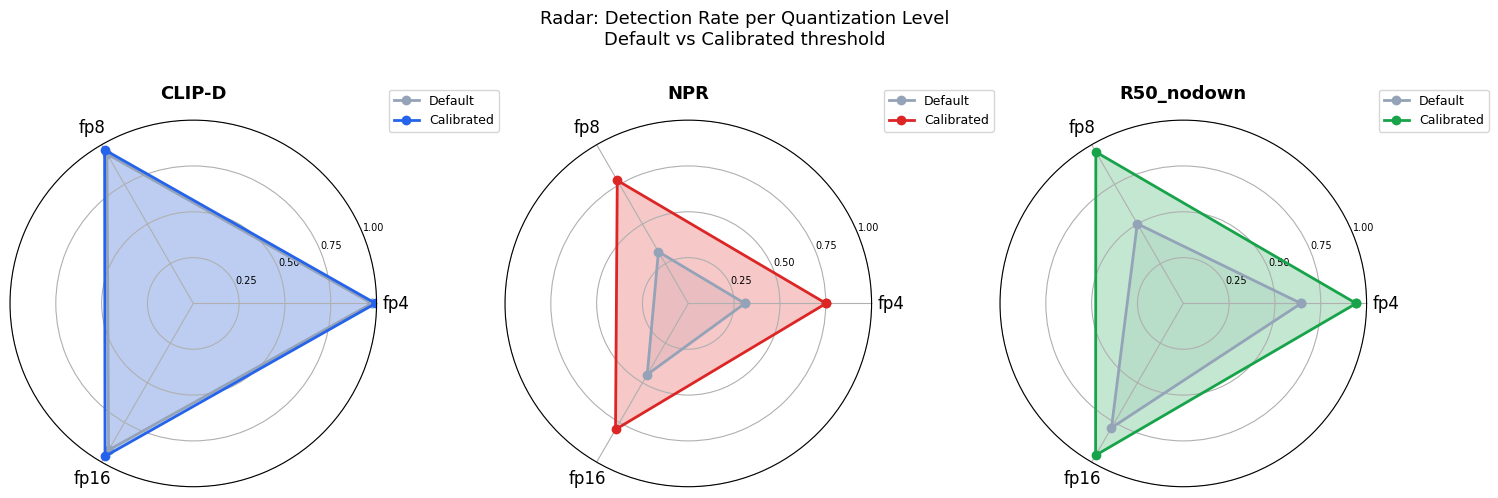

Plot 10 saved.


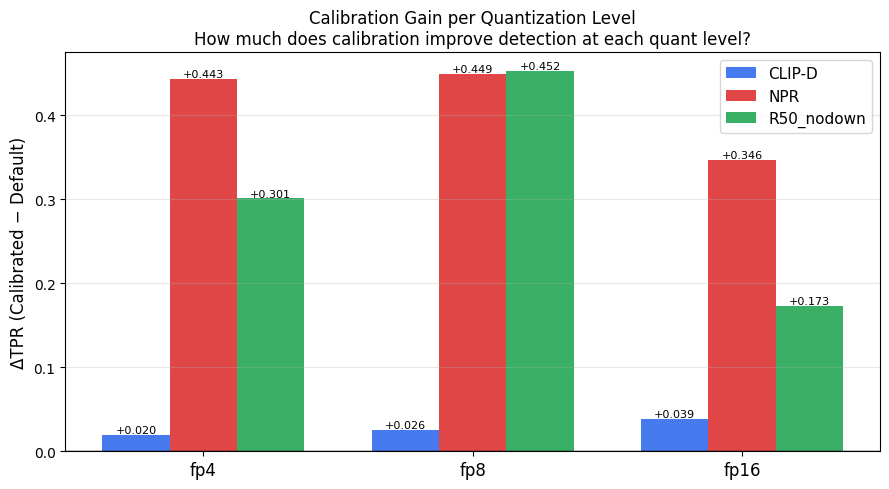

Plot 11 saved.


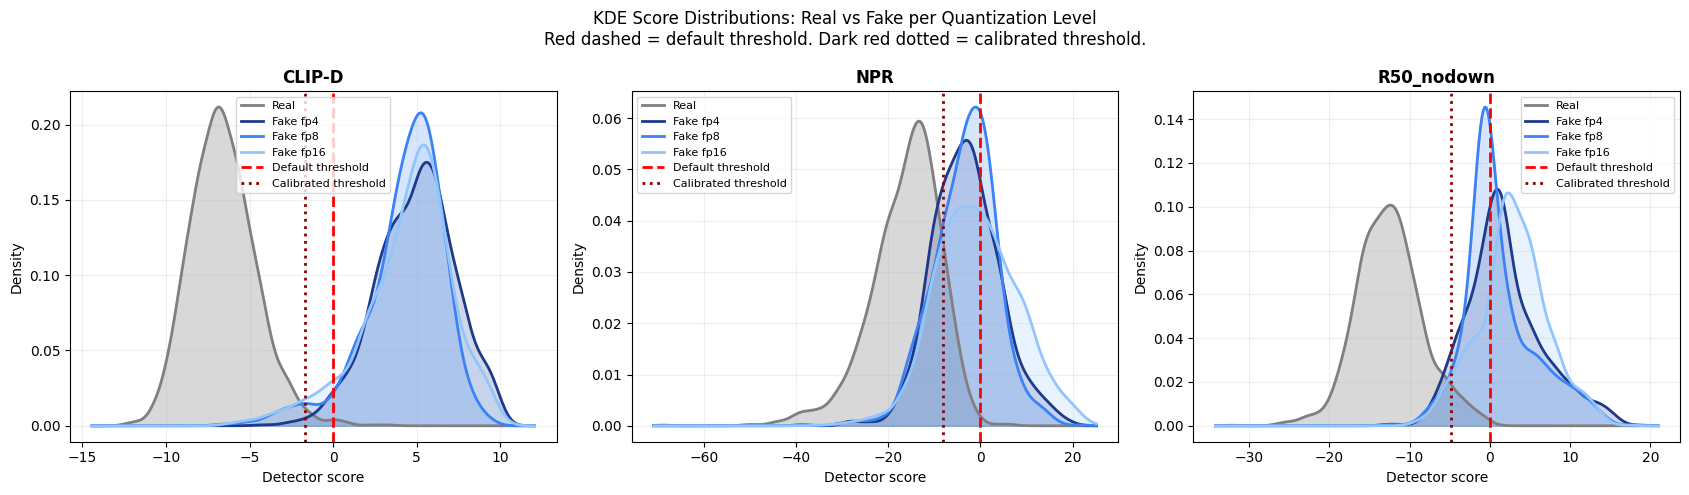

Plot 12 saved.


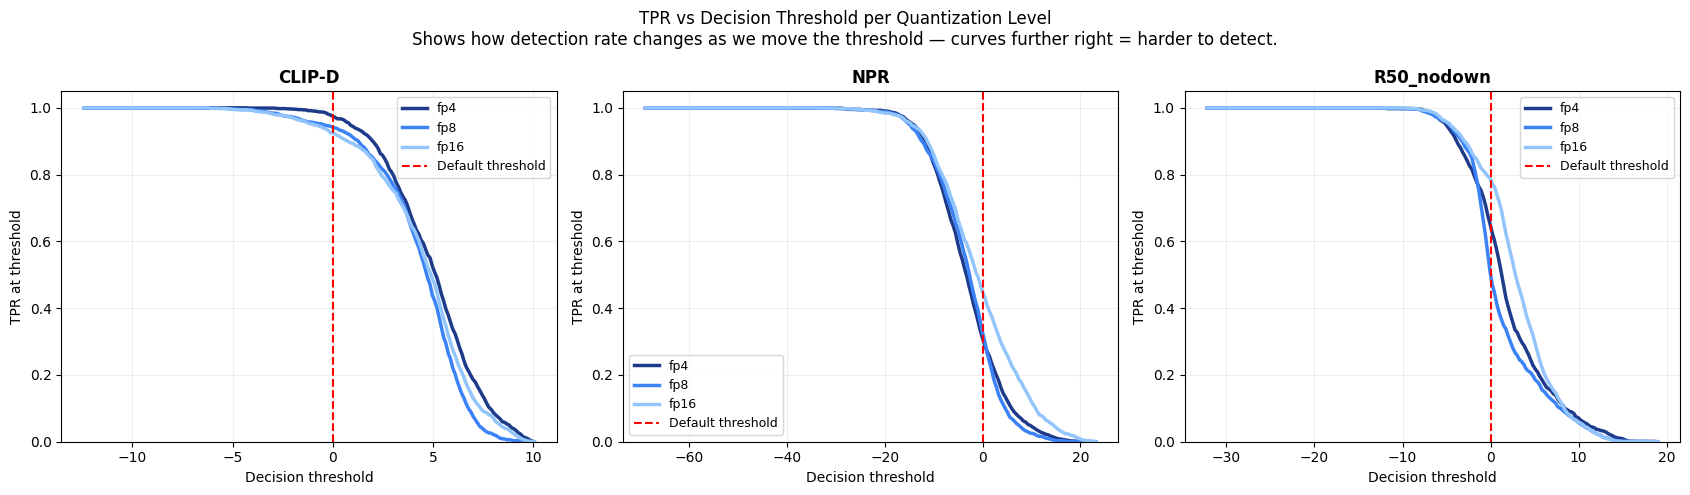

Plot 13 saved.


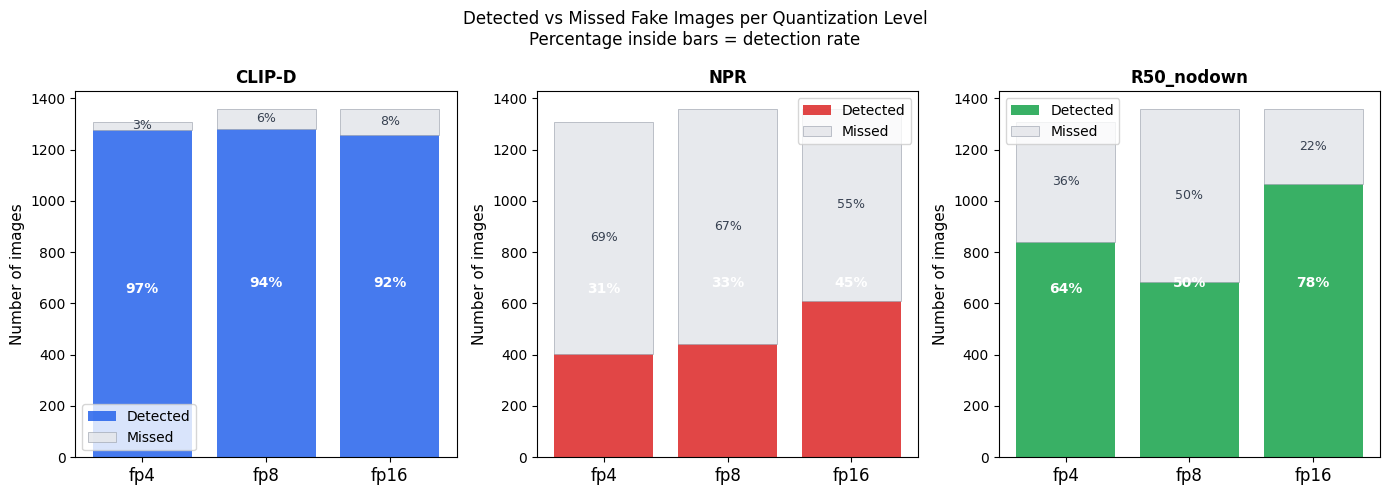

Plot 14 saved.


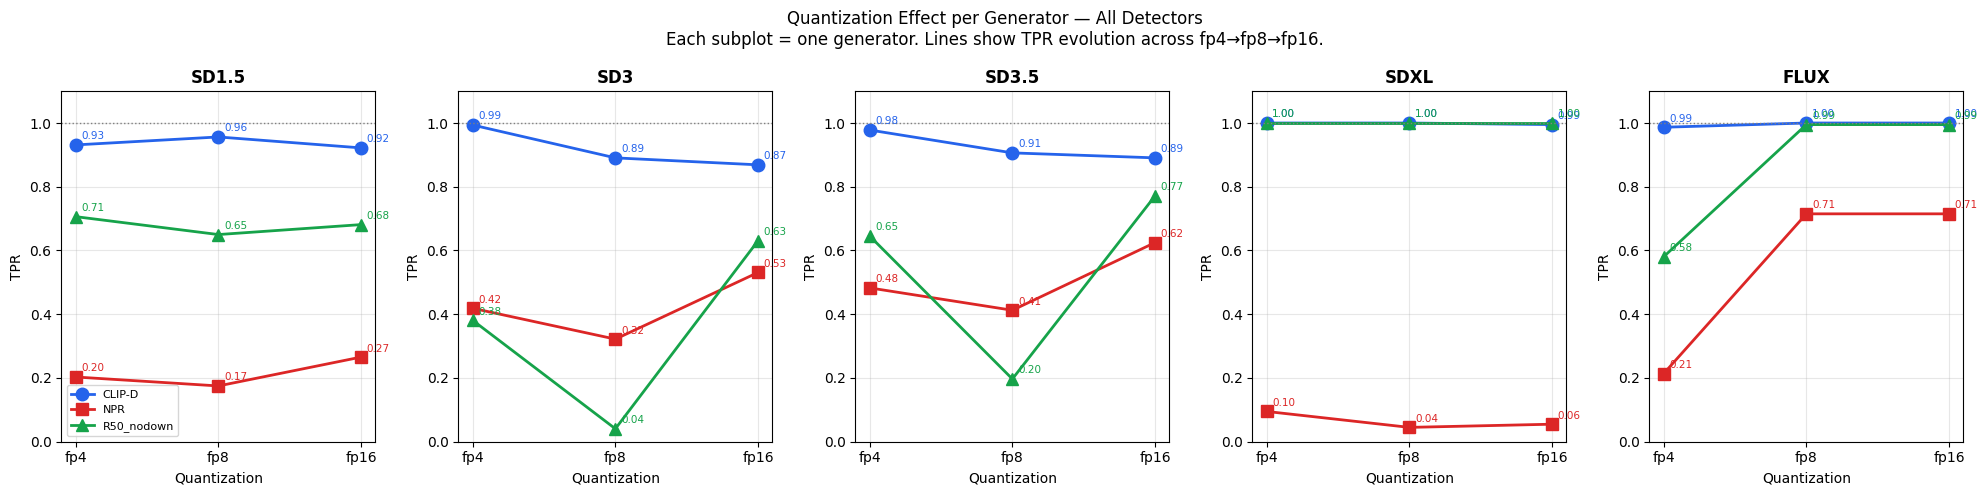

Plot 15 saved.


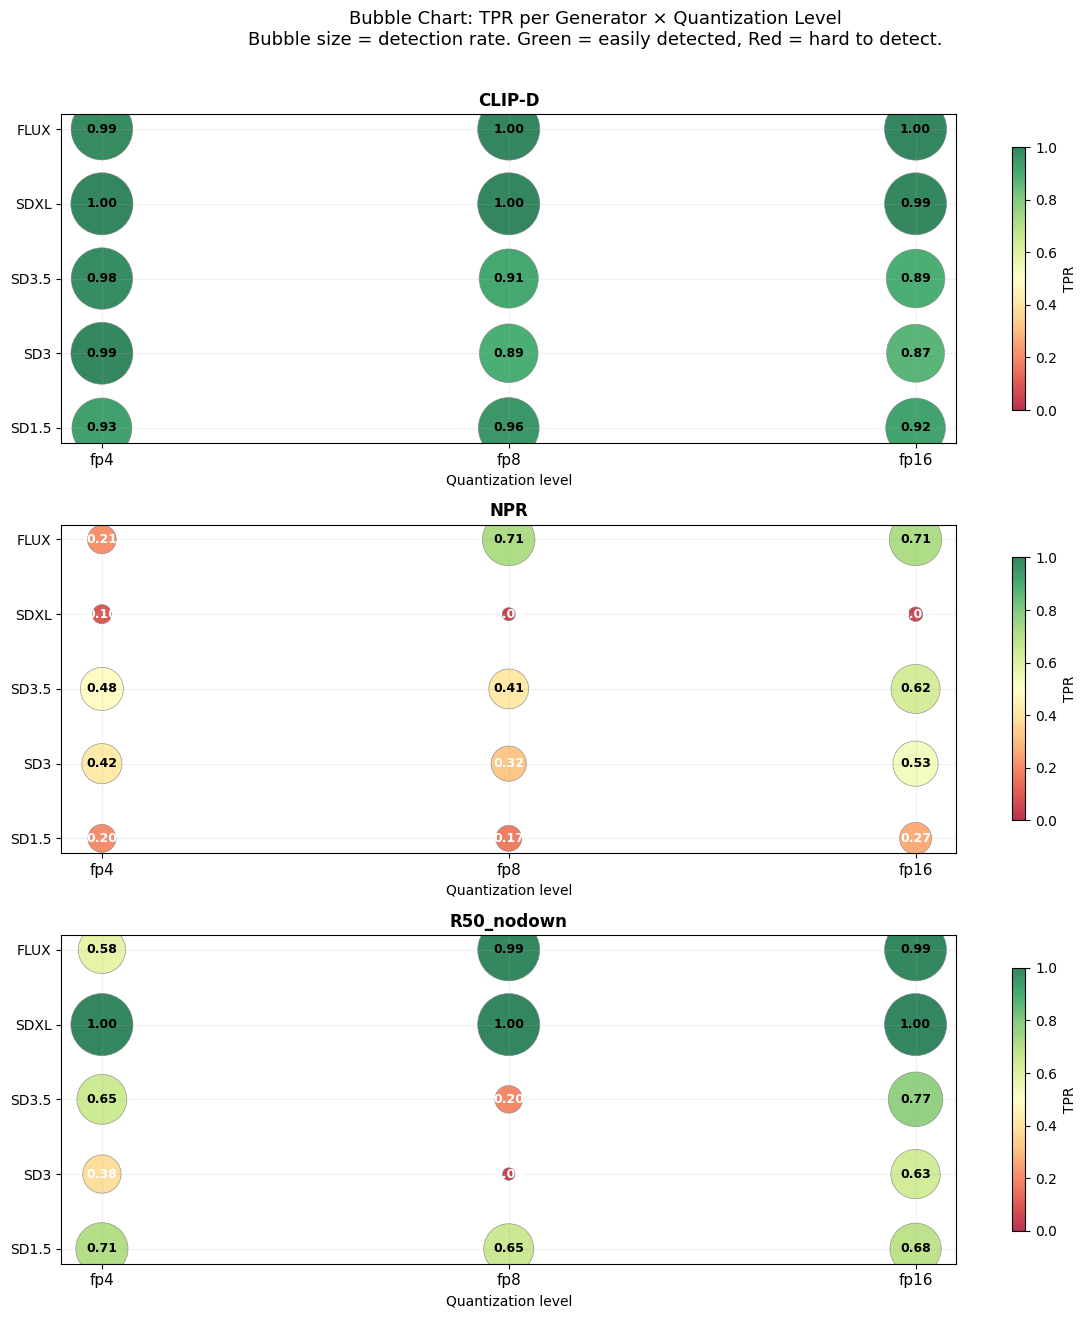

Plot 16 saved.


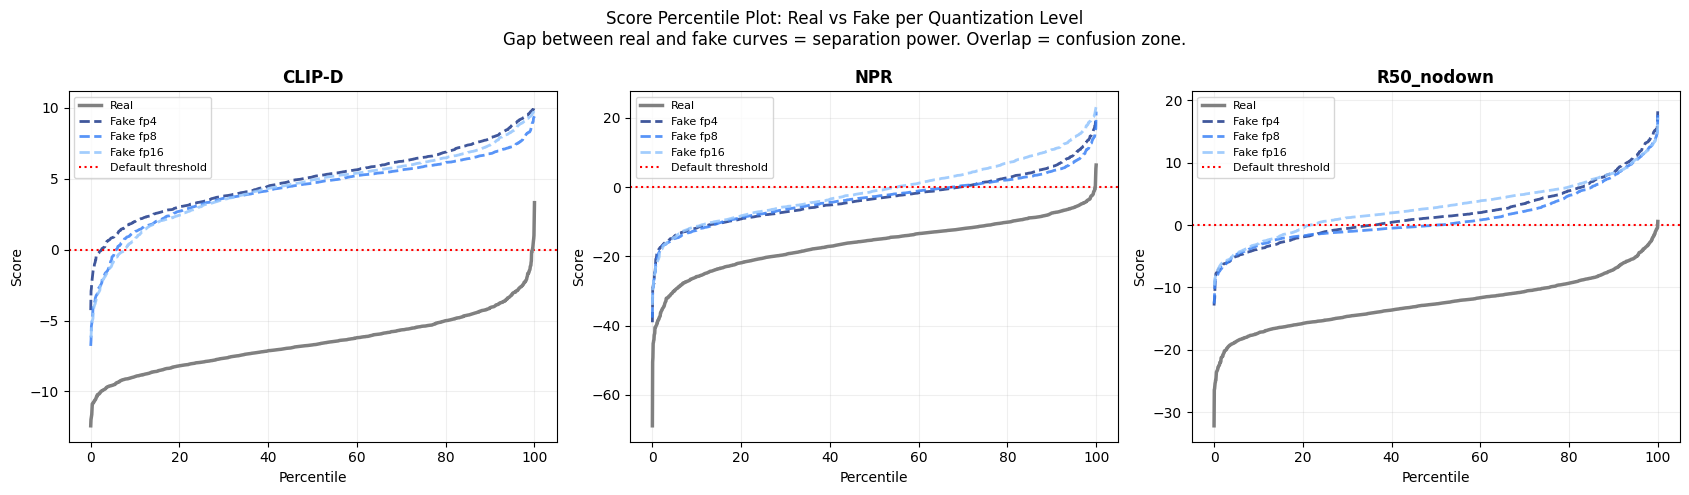

Plot 17 saved.


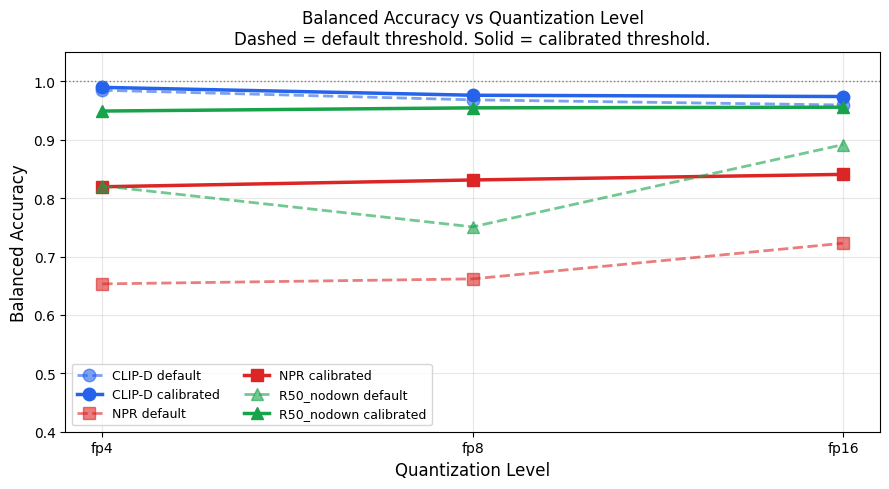

Plot 18 saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All plots downloaded.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import roc_auc_score, accuracy_score, balanced_accuracy_score
from sklearn.model_selection import train_test_split
from google.colab import files
import os

df = pd.read_csv('/content/all_results.csv')
df.columns = df.columns.str.strip()
df['path'] = df['path'].str.strip()

def get_probs(s): return 1/(1+np.exp(-np.array(s, dtype=float)))
def get_preds(det, s):
    p = get_probs(s)
    return (p>0.5).astype(int) if det=='NPR' else (np.array(s)>0).astype(int)

DETS     = ['CLIP-D', 'NPR', 'R50_nodown']
QUANTS   = ['fp4', 'fp8', 'fp16']
GENS     = ['StableDiffusion1.5','StableDiffusion3','StableDiffusion3.5',
            'StableDiffusionXL','FLUX.1']
gen_short = {'StableDiffusion1.5':'SD1.5','StableDiffusion3':'SD3',
             'StableDiffusion3.5':'SD3.5','StableDiffusionXL':'SDXL','FLUX.1':'FLUX'}
COLORS   = {'CLIP-D':'#2563EB','NPR':'#DC2626','R50_nodown':'#16A34A'}
Q_COLORS = {'fp4':'#1e3a8a','fp8':'#3b82f6','fp16':'#93c5fd'}
DET_MARKERS = {'CLIP-D':'o','NPR':'s','R50_nodown':'^'}

fake_df = df[df['label']==1]
real_df = df[df['label']==0]

# Calibration thresholds
cal_thresholds = {}
for det, g in df.groupby('detector'):
    if len(g['label'].unique())<2: continue
    g=g.copy()
    g['strat_key']=g['label'].astype(str)+'_'+g['quant'].fillna('real')
    min_count=g['strat_key'].value_counts().min()
    if min_count>=2:
        cal,_=train_test_split(g,test_size=0.5,stratify=g['strat_key'],random_state=42)
    else:
        cal,_=train_test_split(g,test_size=0.5,stratify=g['label'],random_state=42)
    best_t,best_ba=0.5,0
    probs_cal=get_probs(cal['score'].values)
    for t in np.percentile(probs_cal,np.arange(1,100)):
        preds=(probs_cal>t).astype(int)
        ba=balanced_accuracy_score(cal['label'].values,preds)
        if ba>best_ba: best_ba,best_t=ba,t
    cal_thresholds[det]=best_t

from matplotlib.patches import FancyArrowPatch

fig, axes = plt.subplots(1, 3, figsize=(15,5), subplot_kw=dict(polar=True))
angles = np.linspace(0, 2*np.pi, len(QUANTS), endpoint=False).tolist()
angles += angles[:1]

for ax, det in zip(axes, DETS):
    dg = fake_df[fake_df['detector']==det]
    vals_def=[]; vals_cal=[]
    for q in QUANTS:
        qg=dg[dg['quant']==q]
        vals_def.append(get_preds(det,qg['score'].values).mean() if len(qg) else 0)
        vals_cal.append((get_probs(qg['score'].values)>cal_thresholds[det]).astype(int).mean()
                        if len(qg) else 0)
    vals_def+=vals_def[:1]; vals_cal+=vals_cal[:1]
    ax.plot(angles, vals_def, 'o-', linewidth=2, color='#94A3B8', label='Default')
    ax.fill(angles, vals_def, alpha=0.15, color='#94A3B8')
    ax.plot(angles, vals_cal, 'o-', linewidth=2, color=COLORS[det], label='Calibrated')
    ax.fill(angles, vals_cal, alpha=0.25, color=COLORS[det])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(QUANTS, fontsize=12)
    ax.set_ylim(0,1)
    ax.set_yticks([0.25,0.5,0.75,1.0])
    ax.set_yticklabels(['0.25','0.50','0.75','1.00'], fontsize=7)
    ax.set_title(det, fontsize=13, fontweight='bold', pad=15)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35,1.1), fontsize=9)

plt.suptitle('Radar: Detection Rate per Quantization Level\n'
             'Default vs Calibrated threshold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/content/plot10_radar_quant.png', dpi=150, bbox_inches='tight')
plt.show(); print('Plot 10 saved.')

fig, ax = plt.subplots(figsize=(9,5))
x = np.arange(len(QUANTS)); width = 0.25
for i, det in enumerate(DETS):
    dg = fake_df[fake_df['detector']==det]
    deltas = []
    for q in QUANTS:
        qg = dg[dg['quant']==q]
        if not len(qg): deltas.append(0); continue
        tpr_def = get_preds(det, qg['score'].values).mean()
        tpr_cal = (get_probs(qg['score'].values)>cal_thresholds[det]).astype(int).mean()
        deltas.append(tpr_cal - tpr_def)
    bars = ax.bar(x+i*width, deltas, width, label=det, color=COLORS[det], alpha=0.85)
    for bar in bars:
        h=bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.002 if h>=0 else h-0.012,
                f'+{h:.3f}' if h>=0 else f'{h:.3f}',
                ha='center', fontsize=8)
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(x+width); ax.set_xticklabels(QUANTS, fontsize=12)
ax.set_ylabel('ΔTPR (Calibrated − Default)', fontsize=12)
ax.set_title('Calibration Gain per Quantization Level\n'
             'How much does calibration improve detection at each quant level?', fontsize=12)
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/plot11_delta_tpr.png', dpi=150); plt.show()
print('Plot 11 saved.')

from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1,3, figsize=(17,5))
for ax, det in zip(axes, DETS):
    dg = df[df['detector']==det]
    real_s = dg[dg['label']==0]['score'].values
    x_range = np.linspace(dg['score'].min()-2, dg['score'].max()+2, 300)

    kde_real = gaussian_kde(real_s)
    ax.fill_between(x_range, kde_real(x_range), alpha=0.3, color='gray')
    ax.plot(x_range, kde_real(x_range), color='gray', linewidth=2, label='Real')

    for q in QUANTS:
        fake_s = dg[(dg['label']==1)&(dg['quant']==q)]['score'].values
        if len(fake_s)>1:
            kde_fake = gaussian_kde(fake_s)
            ax.fill_between(x_range, kde_fake(x_range), alpha=0.2, color=Q_COLORS[q])
            ax.plot(x_range, kde_fake(x_range), color=Q_COLORS[q],
                    linewidth=2, label=f'Fake {q}')

    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Default threshold')
    ax.axvline(np.log(cal_thresholds[det]/(1-cal_thresholds[det])) if 0<cal_thresholds[det]<1 else cal_thresholds[det],
               color='darkred', linestyle=':', linewidth=2, label='Calibrated threshold')
    ax.set_title(f'{det}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Detector score', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=8); ax.grid(alpha=0.2)

plt.suptitle('KDE Score Distributions: Real vs Fake per Quantization Level\n'
             'Red dashed = default threshold. Dark red dotted = calibrated threshold.',
             fontsize=12)
plt.tight_layout()
plt.savefig('/content/plot12_kde_distributions.png', dpi=150); plt.show()
print('Plot 12 saved.')

fig, axes = plt.subplots(1,3, figsize=(17,5))
for ax, det in zip(axes, DETS):
    dg = fake_df[fake_df['detector']==det]
    thresholds = np.linspace(df[df['detector']==det]['score'].min(),
                             df[df['detector']==det]['score'].max(), 200)
    for q in QUANTS:
        scores = dg[dg['quant']==q]['score'].values
        if not len(scores): continue
        tprs = [(scores > t).mean() for t in thresholds]
        ax.plot(thresholds, tprs, color=Q_COLORS[q], linewidth=2.5, label=f'{q}')

    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Default threshold')
    ax.set_xlabel('Decision threshold', fontsize=10)
    ax.set_ylabel('TPR at threshold', fontsize=10)
    ax.set_title(f'{det}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.2)
    ax.set_ylim(0,1.05)

plt.suptitle('TPR vs Decision Threshold per Quantization Level\n'
             'Shows how detection rate changes as we move the threshold — '
             'curves further right = harder to detect.',
             fontsize=12)
plt.tight_layout()
plt.savefig('/content/plot13_tpr_vs_threshold.png', dpi=150); plt.show()
print('Plot 13 saved.')

fig, axes = plt.subplots(1,3, figsize=(14,5))
for ax, det in zip(axes, DETS):
    dg = fake_df[fake_df['detector']==det]
    detected=[]; missed=[]
    for q in QUANTS:
        qg = dg[dg['quant']==q]
        preds = get_preds(det, qg['score'].values)
        detected.append(preds.sum())
        missed.append((preds==0).sum())
    x = np.arange(len(QUANTS))
    b1=ax.bar(x, detected, color=COLORS[det], alpha=0.85, label='Detected')
    b2=ax.bar(x, missed, bottom=detected, color='#E5E7EB', alpha=0.9,
              edgecolor='#9CA3AF', linewidth=0.5, label='Missed')
    for xi,(d,m) in enumerate(zip(detected,missed)):
        total=d+m
        ax.text(xi, total/2, f'{d/total:.0%}', ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')
        ax.text(xi, d+m/2, f'{m/total:.0%}', ha='center', va='center',
                fontsize=9, color='#374151')
    ax.set_xticks(x); ax.set_xticklabels(QUANTS, fontsize=12)
    ax.set_ylabel('Number of images', fontsize=11)
    ax.set_title(f'{det}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)

plt.suptitle('Detected vs Missed Fake Images per Quantization Level\n'
             'Percentage inside bars = detection rate', fontsize=12)
plt.tight_layout()
plt.savefig('/content/plot14_stacked_detected_missed.png', dpi=150); plt.show()
print('Plot 14 saved.')

fig, axes = plt.subplots(1, 5, figsize=(20,5))
for ax, gen in zip(axes, GENS):
    dg = fake_df[fake_df['generator']==gen]
    for det in DETS:
        dd = dg[dg['detector']==det]
        tprs=[]
        for q in QUANTS:
            qg = dd[dd['quant']==q]
            tprs.append(get_preds(det,qg['score'].values).mean() if len(qg) else None)
        valid_q=[q for q,v in zip(QUANTS,tprs) if v is not None]
        valid_v=[v for v in tprs if v is not None]
        ax.plot(valid_q, valid_v, marker=DET_MARKERS[det], color=COLORS[det],
                linewidth=2, markersize=9, label=det)
        for q,v in zip(valid_q,valid_v):
            ax.annotate(f'{v:.2f}', (q,v), textcoords='offset points',
                        xytext=(4,4), fontsize=7.5, color=COLORS[det])
    ax.set_ylim(0,1.1)
    ax.set_title(gen_short[gen], fontsize=12, fontweight='bold')
    ax.set_xlabel('Quantization', fontsize=10)
    ax.set_ylabel('TPR', fontsize=10)
    ax.grid(alpha=0.3); ax.axhline(1.0,color='gray',linestyle=':',linewidth=1)
    if gen==GENS[0]: ax.legend(fontsize=8)

plt.suptitle('Quantization Effect per Generator — All Detectors\n'
             'Each subplot = one generator. Lines show TPR evolution across fp4→fp8→fp16.',
             fontsize=12)
plt.tight_layout()
plt.savefig('/content/plot15_per_gen_quant_lines.png', dpi=150); plt.show()
print('Plot 15 saved.')

fig, axes = plt.subplots(3,1, figsize=(12,13))
for ax, det in zip(axes, DETS):
    dg = fake_df[fake_df['detector']==det]
    x_pos=[]; y_pos=[]; sizes=[]; colors_b=[]
    q_idx={'fp4':0,'fp8':1,'fp16':2}
    g_idx={g:i for i,g in enumerate(GENS)}
    for q in QUANTS:
        for gen in GENS:
            gg=dg[(dg['quant']==q)&(dg['generator']==gen)]
            if not len(gg): continue
            tpr=get_preds(det,gg['score'].values).mean()
            x_pos.append(q_idx[q])
            y_pos.append(g_idx[gen])
            sizes.append(tpr*2000)
            colors_b.append(tpr)

    sc=ax.scatter(x_pos, y_pos, s=sizes, c=colors_b, cmap='RdYlGn',
                  vmin=0, vmax=1, alpha=0.8, edgecolors='gray', linewidth=0.5)
    for xi,yi,si,ci in zip(x_pos,y_pos,sizes,colors_b):
        ax.text(xi, yi, f'{ci:.2f}', ha='center', va='center',
                fontsize=9, fontweight='bold',
                color='white' if ci<0.4 else 'black')
    ax.set_xticks([0,1,2]); ax.set_xticklabels(QUANTS, fontsize=11)
    ax.set_yticks(range(len(GENS)))
    ax.set_yticklabels([gen_short[g] for g in GENS], fontsize=10)
    ax.set_title(f'{det}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Quantization level', fontsize=10)
    ax.grid(alpha=0.2)
    plt.colorbar(sc, ax=ax, shrink=0.8, label='TPR')

plt.suptitle('Bubble Chart: TPR per Generator × Quantization Level\n'
             'Bubble size = detection rate. Green = easily detected, Red = hard to detect.',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('/content/plot16_bubble_chart.png', dpi=150, bbox_inches='tight')
plt.show(); print('Plot 16 saved.')

fig, axes = plt.subplots(1,3, figsize=(17,5))
for ax, det in zip(axes, DETS):
    dg = df[df['detector']==det]
    real_s = np.sort(dg[dg['label']==0]['score'].values)
    pcts = np.linspace(0,100,len(real_s))
    ax.plot(pcts, real_s, color='gray', linewidth=2.5, label='Real', zorder=5)

    for q in QUANTS:
        fake_s = np.sort(dg[(dg['label']==1)&(dg['quant']==q)]['score'].values)
        pcts_f = np.linspace(0,100,len(fake_s))
        ax.plot(pcts_f, fake_s, color=Q_COLORS[q], linewidth=2,
                linestyle='--', label=f'Fake {q}', alpha=0.85)

    ax.axhline(0, color='red', linestyle=':', linewidth=1.5, label='Default threshold')
    ax.set_xlabel('Percentile', fontsize=10)
    ax.set_ylabel('Score', fontsize=10)
    ax.set_title(f'{det}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.2)

plt.suptitle('Score Percentile Plot: Real vs Fake per Quantization Level\n'
             'Gap between real and fake curves = separation power. '
             'Overlap = confusion zone.',
             fontsize=12)
plt.tight_layout()
plt.savefig('/content/plot17_percentile_curves.png', dpi=150); plt.show()
print('Plot 17 saved.')

fig, ax = plt.subplots(figsize=(9,5))
for det in DETS:
    dg = df[df['detector']==det]
    real_d = dg[dg['label']==0]
    ba_def=[]; ba_cal=[]
    for q in QUANTS:
        fake_q = dg[(dg['label']==1)&(dg['quant']==q)]
        if not len(fake_q): ba_def.append(0); ba_cal.append(0); continue
        sub = pd.concat([fake_q, real_d])
        l=sub['label'].values
        preds_def=get_preds(det,sub['score'].values)
        preds_cal=(get_probs(sub['score'].values)>cal_thresholds[det]).astype(int)
        ba_def.append(balanced_accuracy_score(l,preds_def))
        ba_cal.append(balanced_accuracy_score(l,preds_cal))

    ax.plot(QUANTS, ba_def, marker=DET_MARKERS[det], color=COLORS[det],
            linewidth=2, linestyle='--', markersize=9, alpha=0.6,
            label=f'{det} default')
    ax.plot(QUANTS, ba_cal, marker=DET_MARKERS[det], color=COLORS[det],
            linewidth=2.5, linestyle='-', markersize=9,
            label=f'{det} calibrated')

ax.set_ylim(0.4,1.05)
ax.set_ylabel('Balanced Accuracy', fontsize=12)
ax.set_xlabel('Quantization Level', fontsize=12)
ax.set_title('Balanced Accuracy vs Quantization Level\n'
             'Dashed = default threshold. Solid = calibrated threshold.', fontsize=12)
ax.legend(fontsize=9, ncol=2); ax.grid(alpha=0.3)
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1)
plt.tight_layout()
plt.savefig('/content/plot18_balacc_evolution.png', dpi=150); plt.show()
print('Plot 18 saved.')

new_plots = [f'/content/plot{i}_{n}.png' for i,n in [
    (10,'radar_quant'),(11,'delta_tpr'),(12,'kde_distributions'),
    (13,'tpr_vs_threshold'),(14,'stacked_detected_missed'),
    (15,'per_gen_quant_lines'),(16,'bubble_chart'),
    (17,'percentile_curves'),(18,'balacc_evolution')
]]
for f in new_plots:
    if os.path.exists(f):
        files.download(f)
print('\nAll plots downloaded.')

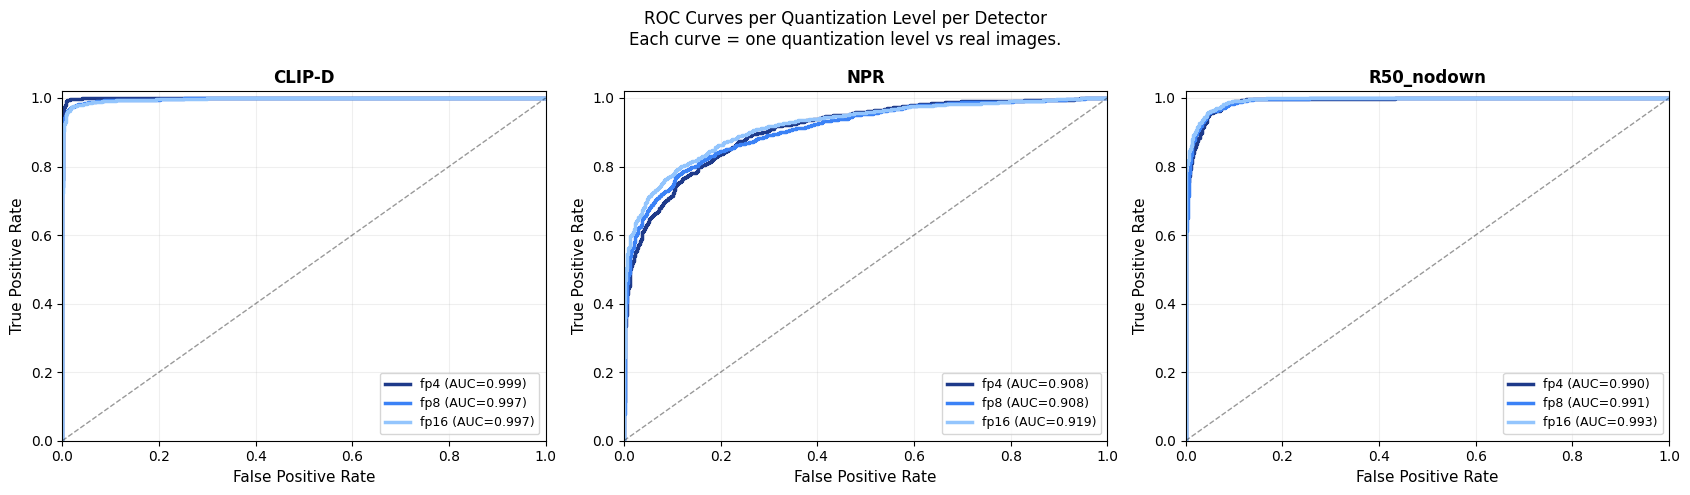

Plot 19 saved.


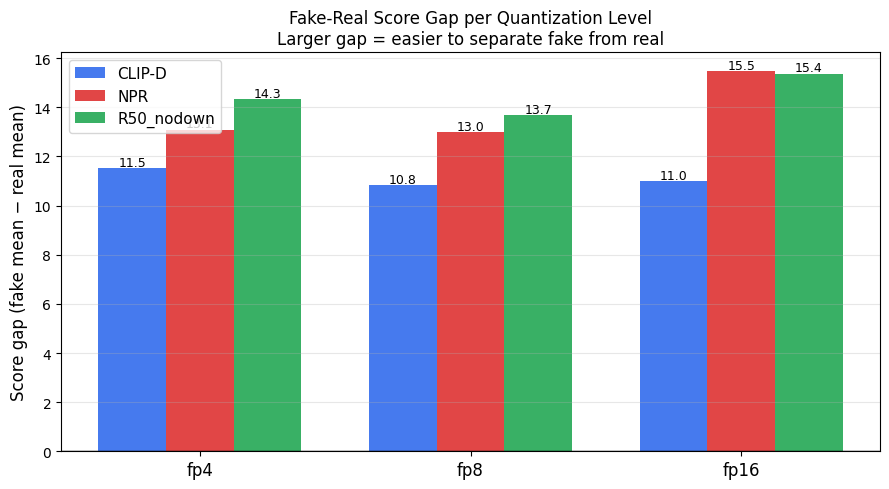

Plot 20 saved.


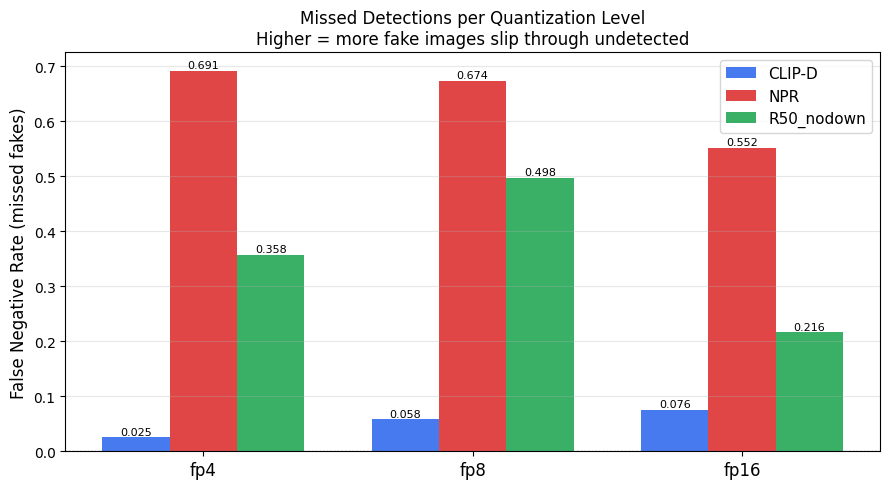

Plot 21 saved.


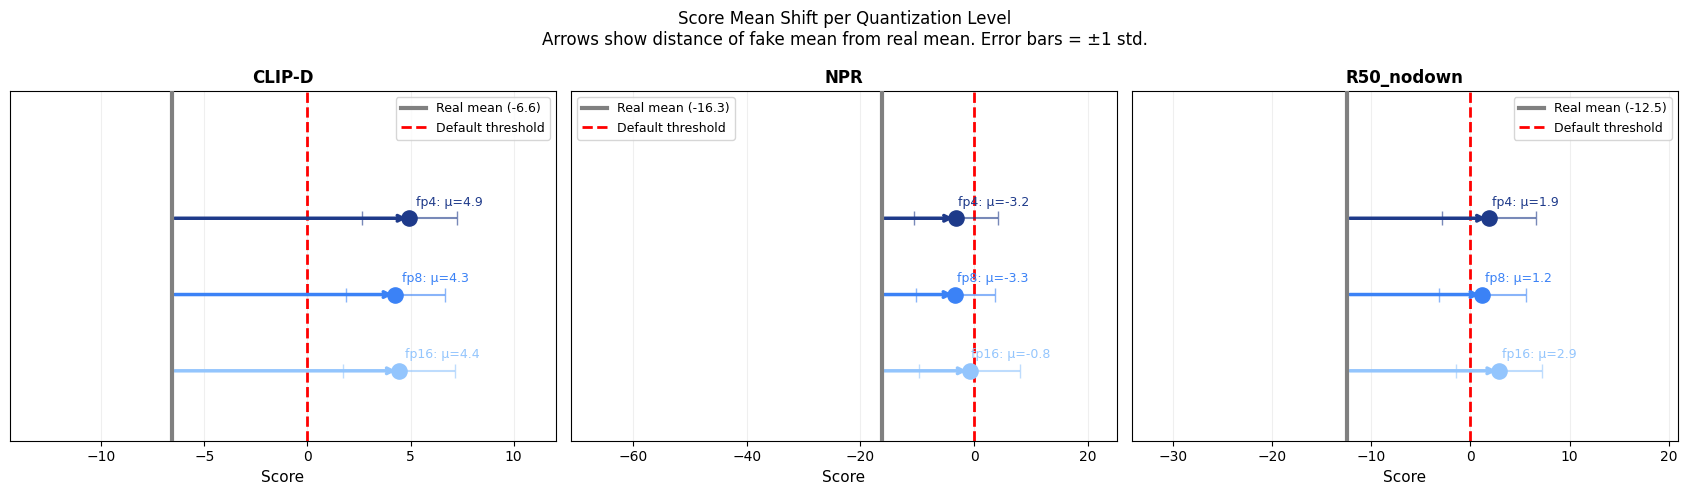

Plot 22 saved.


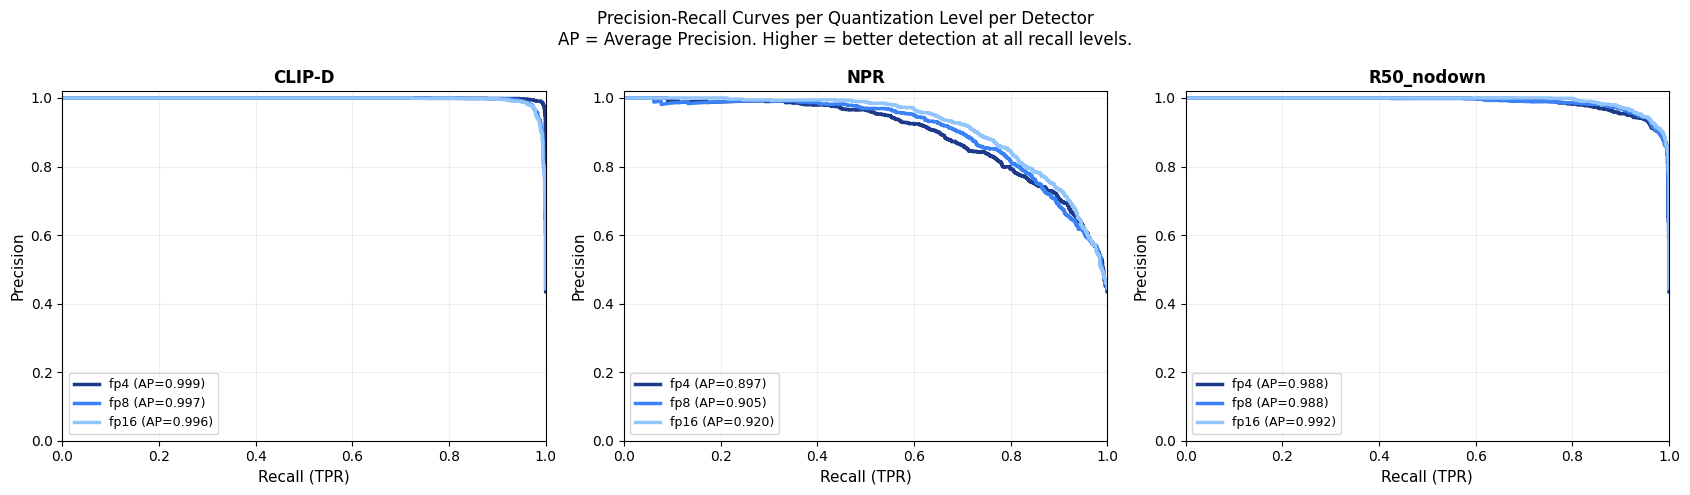

Plot 23 saved.


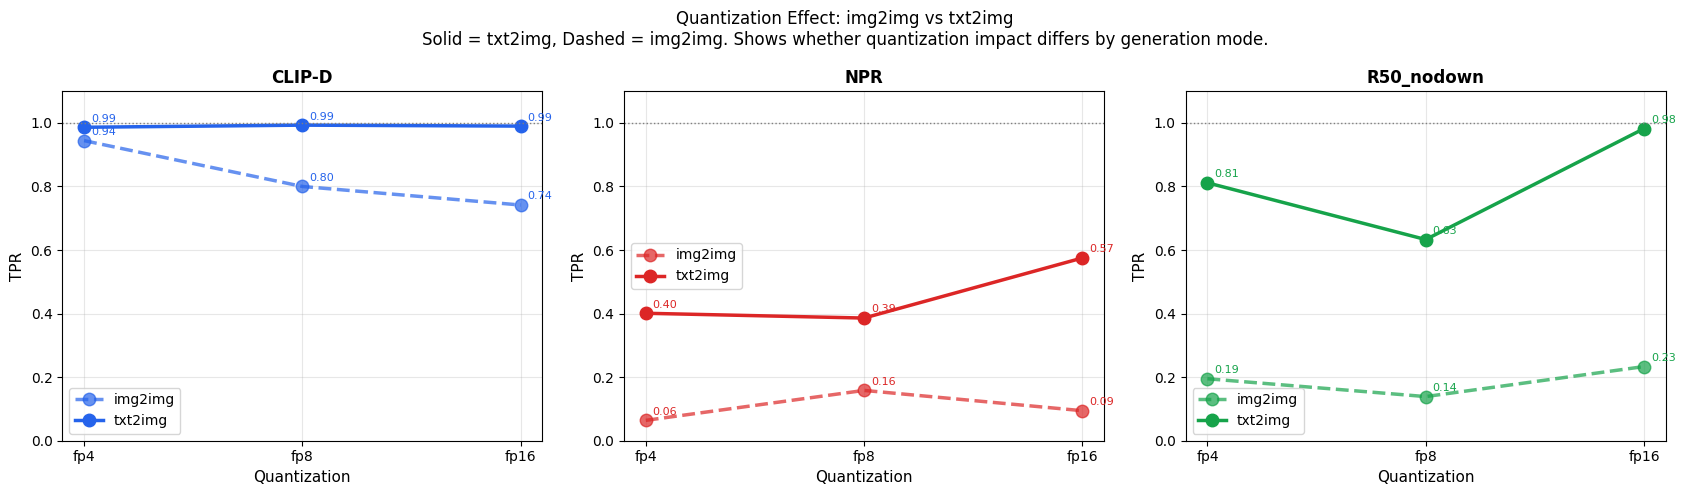

Plot 24 saved.


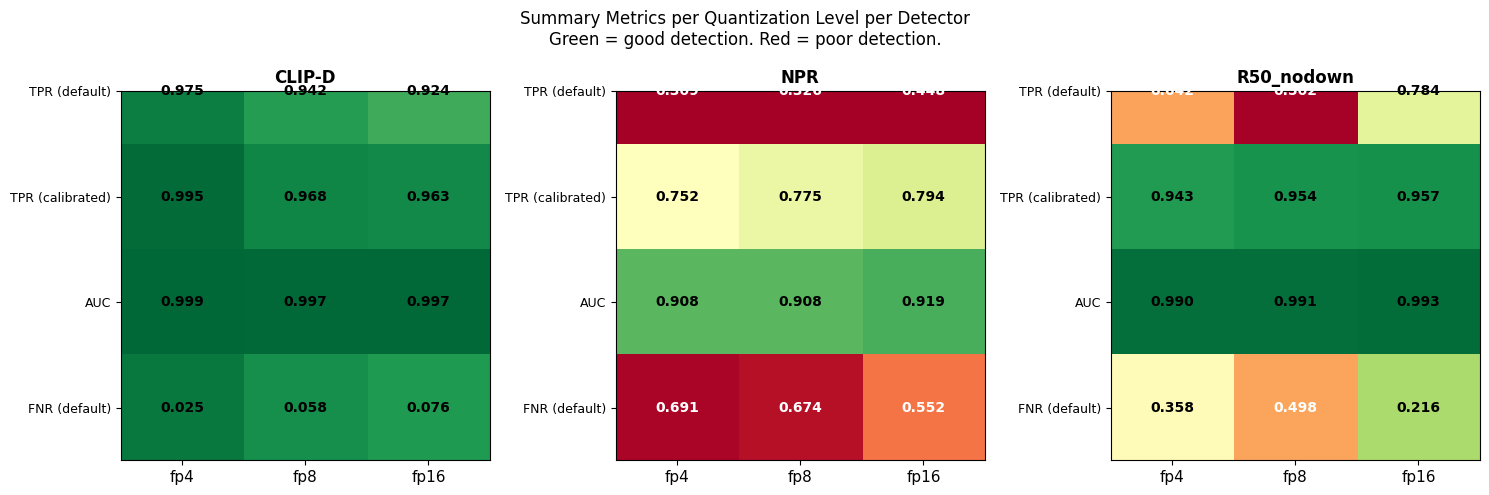

Plot 25 saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All downloaded.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score, balanced_accuracy_score, roc_curve
from sklearn.model_selection import train_test_split
from scipy.stats import gaussian_kde
from google.colab import files
import os

df = pd.read_csv('/content/all_results.csv')
df.columns = df.columns.str.strip()
df['path'] = df['path'].str.strip()

def get_probs(s): return 1/(1+np.exp(-np.array(s, dtype=float)))
def get_preds(det, s):
    p = get_probs(s)
    return (p>0.5).astype(int) if det=='NPR' else (np.array(s)>0).astype(int)

DETS     = ['CLIP-D','NPR','R50_nodown']
QUANTS   = ['fp4','fp8','fp16']
GENS     = ['StableDiffusion1.5','StableDiffusion3','StableDiffusion3.5','StableDiffusionXL','FLUX.1']
gen_short= {'StableDiffusion1.5':'SD1.5','StableDiffusion3':'SD3',
            'StableDiffusion3.5':'SD3.5','StableDiffusionXL':'SDXL','FLUX.1':'FLUX'}
COLORS   = {'CLIP-D':'#2563EB','NPR':'#DC2626','R50_nodown':'#16A34A'}
Q_COLORS = {'fp4':'#1e3a8a','fp8':'#3b82f6','fp16':'#93c5fd'}
DET_MARKERS = {'CLIP-D':'o','NPR':'s','R50_nodown':'^'}

fake_df = df[df['label']==1]
real_df = df[df['label']==0]

# Calibration
cal_thresholds={}
for det, g in df.groupby('detector'):
    if len(g['label'].unique())<2: continue
    g=g.copy()
    g['strat_key']=g['label'].astype(str)+'_'+g['quant'].fillna('real')
    min_count=g['strat_key'].value_counts().min()
    if min_count>=2:
        cal,_=train_test_split(g,test_size=0.5,stratify=g['strat_key'],random_state=42)
    else:
        cal,_=train_test_split(g,test_size=0.5,stratify=g['label'],random_state=42)
    best_t,best_ba=0.5,0
    probs_cal=get_probs(cal['score'].values)
    for t in np.percentile(probs_cal,np.arange(1,100)):
        preds=(probs_cal>t).astype(int)
        ba=balanced_accuracy_score(cal['label'].values,preds)
        if ba>best_ba: best_ba,best_t=ba,t
    cal_thresholds[det]=best_t

fig, axes = plt.subplots(1,3, figsize=(17,5))
for ax, det in zip(axes, DETS):
    real_s = real_df[real_df['detector']==det]['score'].values
    real_l = real_df[real_df['detector']==det]['label'].values
    dg = fake_df[fake_df['detector']==det]
    for q in QUANTS:
        qg = dg[dg['quant']==q]
        if not len(qg): continue
        all_s = np.concatenate([real_s, qg['score'].values])
        all_l = np.concatenate([real_l, qg['label'].values])
        fpr, tpr, _ = roc_curve(all_l, get_probs(all_s))
        auc = roc_auc_score(all_l, get_probs(all_s))
        ax.plot(fpr, tpr, color=Q_COLORS[q], linewidth=2.5,
                label=f'{q} (AUC={auc:.3f})')
    ax.plot([0,1],[0,1],'k--',linewidth=1,alpha=0.4)
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'{det}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.2)
    ax.set_xlim(0,1); ax.set_ylim(0,1.02)

plt.suptitle('ROC Curves per Quantization Level per Detector\n'
             'Each curve = one quantization level vs real images.',fontsize=12)
plt.tight_layout()
plt.savefig('/content/plot19_roc_curves.png',dpi=150); plt.show()
print('Plot 19 saved.')

fig, ax = plt.subplots(figsize=(9,5))
x = np.arange(len(QUANTS)); width=0.25
for i, det in enumerate(DETS):
    dg = df[df['detector']==det]
    real_mean = dg[dg['label']==0]['score'].mean()
    gaps=[]
    for q in QUANTS:
        fake_mean = dg[(dg['label']==1)&(dg['quant']==q)]['score'].mean()
        gaps.append(fake_mean - real_mean)
    bars=ax.bar(x+i*width, gaps, width, label=det, color=COLORS[det], alpha=0.85)
    for bar in bars:
        h=bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.1 if h>=0 else h-0.3,
                f'{h:.1f}', ha='center', fontsize=9)
ax.axhline(0,color='black',linewidth=1)
ax.set_xticks(x+width); ax.set_xticklabels(QUANTS,fontsize=12)
ax.set_ylabel('Score gap (fake mean − real mean)', fontsize=12)
ax.set_title('Fake-Real Score Gap per Quantization Level\n'
             'Larger gap = easier to separate fake from real',fontsize=12)
ax.legend(fontsize=11); ax.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig('/content/plot20_score_gap.png',dpi=150); plt.show()
print('Plot 20 saved.')


fig, ax = plt.subplots(figsize=(9,5))
x = np.arange(len(QUANTS)); width=0.25
for i, det in enumerate(DETS):
    dg = fake_df[fake_df['detector']==det]
    fnrs=[]
    for q in QUANTS:
        qg=dg[dg['quant']==q]
        tpr=get_preds(det,qg['score'].values).mean() if len(qg) else 0
        fnrs.append(1-tpr)
    bars=ax.bar(x+i*width, fnrs, width, label=det, color=COLORS[det], alpha=0.85)
    for bar in bars:
        h=bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.005,
                f'{h:.3f}', ha='center', fontsize=8)
ax.set_xticks(x+width); ax.set_xticklabels(QUANTS,fontsize=12)
ax.set_ylabel('False Negative Rate (missed fakes)', fontsize=12)
ax.set_title('Missed Detections per Quantization Level\n'
             'Higher = more fake images slip through undetected',fontsize=12)
ax.legend(fontsize=11); ax.grid(axis='y',alpha=0.3)
ax.axhline(0,color='gray',linestyle=':',linewidth=1)
plt.tight_layout()
plt.savefig('/content/plot21_fnr_per_quant.png',dpi=150); plt.show()
print('Plot 21 saved.')

fig, axes = plt.subplots(1,3, figsize=(17,5))
for ax, det in zip(axes, DETS):
    dg = df[df['detector']==det]
    real_mean = dg[dg['label']==0]['score'].mean()
    ax.axvline(real_mean, color='gray', linewidth=3, label=f'Real mean ({real_mean:.1f})', zorder=5)
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Default threshold')

    for q in QUANTS:
        fake_s = dg[(dg['label']==1)&(dg['quant']==q)]['score'].values
        if len(fake_s)<2: continue
        m=fake_s.mean(); s=fake_s.std()
        ax.annotate('', xy=(m,0.5-QUANTS.index(q)*0.12),
                    xytext=(real_mean,0.5-QUANTS.index(q)*0.12),
                    arrowprops=dict(arrowstyle='->', color=Q_COLORS[q], lw=2.5))
        ax.scatter([m],[0.5-QUANTS.index(q)*0.12], color=Q_COLORS[q], s=120, zorder=6)
        ax.text(m+0.3, 0.5-QUANTS.index(q)*0.12+0.02,
                f'{q}: μ={m:.1f}', fontsize=9, color=Q_COLORS[q])
        ax.errorbar(m, 0.5-QUANTS.index(q)*0.12, xerr=s, fmt='none',
                    color=Q_COLORS[q], capsize=5, linewidth=1.5, alpha=0.6)

    ax.set_xlim(dg['score'].min()-2, dg['score'].max()+2)
    ax.set_ylim(0.15,0.7)
    ax.set_xlabel('Score', fontsize=11)
    ax.set_yticks([])
    ax.set_title(f'{det}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(axis='x', alpha=0.2)

plt.suptitle('Score Mean Shift per Quantization Level\n'
             'Arrows show distance of fake mean from real mean. '
             'Error bars = ±1 std.',fontsize=12)
plt.tight_layout()
plt.savefig('/content/plot22_mean_shift.png',dpi=150); plt.show()
print('Plot 22 saved.')

from sklearn.metrics import precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1,3, figsize=(17,5))
for ax, det in zip(axes, DETS):
    real_s = real_df[real_df['detector']==det]['score'].values
    real_l = real_df[real_df['detector']==det]['label'].values
    dg = fake_df[fake_df['detector']==det]
    for q in QUANTS:
        qg=dg[dg['quant']==q]
        if not len(qg): continue
        all_s=np.concatenate([real_s,qg['score'].values])
        all_l=np.concatenate([real_l,qg['label'].values])
        prec,rec,_=precision_recall_curve(all_l,get_probs(all_s))
        ap=average_precision_score(all_l,get_probs(all_s))
        ax.plot(rec,prec,color=Q_COLORS[q],linewidth=2.5,
                label=f'{q} (AP={ap:.3f})')
    ax.set_xlabel('Recall (TPR)', fontsize=11)
    ax.set_ylabel('Precision', fontsize=11)
    ax.set_title(f'{det}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.2)
    ax.set_xlim(0,1); ax.set_ylim(0,1.02)

plt.suptitle('Precision-Recall Curves per Quantization Level per Detector\n'
             'AP = Average Precision. Higher = better detection at all recall levels.',fontsize=12)
plt.tight_layout()
plt.savefig('/content/plot23_precision_recall.png',dpi=150); plt.show()
print('Plot 23 saved.')

fig, axes = plt.subplots(1,3, figsize=(17,5))
MODE_STYLE = {'img2img':'--','txt2img':'-'}
MODE_ALPHA  = {'img2img':0.7,'txt2img':1.0}
for ax, det in zip(axes, DETS):
    dg = fake_df[fake_df['detector']==det]
    for q in QUANTS:
        for mode in ['img2img','txt2img']:
            mg=dg[(dg['quant']==q)&(dg['mode']==mode)]
            if not len(mg): continue
    # Line per mode per detector
    for mode,ls in MODE_STYLE.items():
        tprs=[]
        for q in QUANTS:
            mg=dg[(dg['quant']==q)&(dg['mode']==mode)]
            tprs.append(get_preds(det,mg['score'].values).mean() if len(mg) else None)
        valid_q=[q for q,v in zip(QUANTS,tprs) if v is not None]
        valid_v=[v for v in tprs if v is not None]
        ax.plot(valid_q, valid_v, marker='o', linewidth=2.5,
                linestyle=ls, color=COLORS[det],
                alpha=MODE_ALPHA[mode], markersize=9, label=mode)
        for q,v in zip(valid_q,valid_v):
            ax.annotate(f'{v:.2f}',(q,v),textcoords='offset points',
                        xytext=(5,4),fontsize=8,color=COLORS[det])
    ax.set_ylim(0,1.1)
    ax.set_ylabel('TPR',fontsize=11); ax.set_xlabel('Quantization',fontsize=11)
    ax.set_title(f'{det}',fontsize=12,fontweight='bold')
    ax.legend(fontsize=10); ax.grid(alpha=0.3)
    ax.axhline(1.0,color='gray',linestyle=':',linewidth=1)

plt.suptitle('Quantization Effect: img2img vs txt2img\n'
             'Solid = txt2img, Dashed = img2img. '
             'Shows whether quantization impact differs by generation mode.',fontsize=12)
plt.tight_layout()
plt.savefig('/content/plot24_mode_quant_lines.png',dpi=150); plt.show()
print('Plot 24 saved.')

metrics = ['TPR (default)','TPR (calibrated)','AUC','FNR (default)']
fig, axes = plt.subplots(1,3,figsize=(15,5))
for ax, det in zip(axes, DETS):
    dg_all = df[df['detector']==det]
    real_s = real_df[real_df['detector']==det]['score'].values
    real_l = real_df[real_df['detector']==det]['label'].values
    dg = fake_df[fake_df['detector']==det]
    mat=np.zeros((len(metrics),len(QUANTS)))
    for j,q in enumerate(QUANTS):
        qg=dg[dg['quant']==q]
        if not len(qg): continue
        all_s=np.concatenate([real_s,qg['score'].values])
        all_l=np.concatenate([real_l,qg['label'].values])
        tpr_def=get_preds(det,qg['score'].values).mean()
        tpr_cal=(get_probs(qg['score'].values)>cal_thresholds[det]).astype(int).mean()
        auc=roc_auc_score(all_l,get_probs(all_s))
        fnr=1-tpr_def
        mat[:,j]=[tpr_def,tpr_cal,auc,fnr]

    im=ax.imshow(mat[:3], cmap='RdYlGn', vmin=0.5, vmax=1.0, aspect='auto')
    im2=ax.imshow(mat[3:], cmap='RdYlGn_r', vmin=0, vmax=0.7,
                  aspect='auto', extent=[-0.5,2.5,3.5,2.5])
    ax.set_xticks(range(len(QUANTS))); ax.set_yticks(range(len(metrics)))
    ax.set_xticklabels(QUANTS,fontsize=11)
    ax.set_yticklabels(metrics,fontsize=9)
    ax.set_title(f'{det}',fontsize=12,fontweight='bold')
    for i in range(len(metrics)):
        for j in range(len(QUANTS)):
            ax.text(j,i,f'{mat[i,j]:.3f}',ha='center',va='center',
                    fontsize=10,fontweight='bold',
                    color='white' if (i<3 and mat[i,j]<0.7) or
                                     (i==3 and mat[i,j]>0.4) else 'black')

plt.suptitle('Summary Metrics per Quantization Level per Detector\n'
             'Green = good detection. Red = poor detection.',fontsize=12)
plt.tight_layout()
plt.savefig('/content/plot25_summary_heatmap.png',dpi=150); plt.show()
print('Plot 25 saved.')

# Download all
for i,n in [(19,'roc_curves'),(20,'score_gap'),(21,'fnr_per_quant'),
            (22,'mean_shift'),(23,'precision_recall'),
            (24,'mode_quant_lines'),(25,'summary_heatmap')]:
    f=f'/content/plot{i}_{n}.png'
    if os.path.exists(f): files.download(f)
print('All downloaded.')